In [85]:
import torch
import numpy as np
import torchvision
import timm
import math
rng = torch.Generator().manual_seed(22)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import time
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR 

In [86]:
rng = torch.Generator().manual_seed(22)
nprng = np.random.default_rng(22)

## Définition des fonctions utilitaires 

Dans un premier temps, nous définissons la pipeline d'entraînement qui sera utilisée pour nos différents modèles, ainsi que diverses fonctions nous permettant de visualiser les résultats.

- `train_model`: Il s'agit de la fonction pipeline d'entraînement. Elle prend en paramètres un modèle (CNN ou Vit), les données et autres hyperparamètres et renvoie la perte et l'accuracy, ce qui nous permet de suivre l'évolution de l'entraînement. 

    On choisit d'évaluer l'accuracy sur les données d'entraînement ainsi que les données de test à chaque epoch car cela permet de suivre les performances de généralisation des modèles au fil de l'entraînement. Mais nous n'utilisons pas ce score pour validation.

- `plot_loss`, `plot_accuracy`: Ces fonctions nous permettront de visualiser la perte et l'accuracy au fil des epochs d'entraînement pour les deux modèles.



In [203]:
# Pipeline de Training 

def train_model(model, 
              train_loader, 
              test_loader, 
              nb_classes, 
              epochs,
              lr,
              weight_decay,
              loss_function = torch.nn.CrossEntropyLoss(),
              affichage = True):
  """
    Entraîne le modèle et retourne l'historique complet.

    Retourne un dict :
        train_loss  : liste des losses moyennes par epoch
        train_acc   : liste des accuracies train par epoch (%)
        val_acc     : liste des accuracies test par epoch (%)
  """
  optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

  # Choix du scheduler 
  if isinstance(model, Tiny_Vit) or isinstance(model, timm.models.vision_transformer.VisionTransformer):
    warmup_epochs = 5
    # Warmup + Cosine decay
    warmup_scheduler = LinearLR(
        optimizer,
        start_factor = lr,
        total_iters=warmup_epochs
    )

    cosine_scheduler = CosineAnnealingLR(
        optimizer,
        T_max=epochs - warmup_epochs
    )

    scheduler = SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[warmup_epochs]
    )
  else:
     scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

  history = {"train_loss": [], "train_acc": [], "val_acc": []}
  
  for epoch in range(epochs):
        # ── Phase entraînement ─────────────────────────────────────────────
        model.train()
        epoch_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
          outputs = model(images)
          loss = loss_function(outputs, labels)
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          epoch_loss += loss.item() 

          # On calcule l'accuracy (correct/total) par batch 
          preds = outputs.argmax(dim=1) # on prédit la classe avec la plus grande probabilité
          # Remarque : on n'utilise pas de softmax car la fonction de perte CrossEntropyLoss attend des logits et applique elle-même le log-softmax
          correct += (preds == labels).sum().item()
          total += labels.size(0)

        scheduler.step()

        # Accuracy d'entraînement de l'epoch
        epoch_acc = 100 * correct / total

        # ── Phase validation ───────────────────────────────────────────────
        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images, labels
                outputs = model(images)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)
        
        # Accuracy évaluée sur le set de test à la fin de chaque epoch
        val_acc = 100 * val_correct / val_total

        history["train_loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc)
        history["val_acc"].append(val_acc)


        if affichage:
            print(f"Epoch {epoch} | Loss: {epoch_loss:.2f} | Train Acc: {epoch_acc:.3f}% | Val Acc: {val_acc:.3f}%")
        

  return history

In [115]:
# Evaluation et test du modèle
def evaluate_model(model, dataloader, num_classes):

    model.eval()

    correct = 0
    total = 0

    correct_per_class = torch.zeros(num_classes)
    total_per_class = torch.zeros(num_classes)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images, labels

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            for i in range(len(labels)):
                label = labels[i]
                total_per_class[label] += 1
                if preds[i] == label:
                    correct_per_class[label] += 1

            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    accuracy = correct / total
    acc_per_class = correct_per_class / total_per_class

    return accuracy, acc_per_class, (all_labels, all_preds)

In [116]:
def plot_loss(ViT_train_losses, CNN_train_losses, ax):
    ax.plot(ViT_train_losses, marker='o', label='Vision Transformer')
    ax.plot(CNN_train_losses, marker='s', label='Convolutional Neural Network')

    ax.set_title("Perte de Training par Epochs")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

In [136]:
def plot_accuracy(ViT_train_accuracies, CNN_train_accuracies, ax):

    ax.plot(ViT_train_accuracies, marker='o', color='blue', label='Vision Transformer')
    ax.plot(CNN_train_accuracies, marker='s', color='red', label='Convolutional Neural Network')

    ax.set_title("Accuracy par Epochs")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()

In [118]:
def plot_accuracy_per_class(ViT_acc_per_class, CNN_acc_per_class):

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    sns.barplot(x=list(range(len(ViT_acc_per_class))), y=ViT_acc_per_class, ax=axs[0])
    sns.barplot(x=list(range(len(CNN_acc_per_class))), y=CNN_acc_per_class, ax=axs[1])

    axs[0].set_title("Accuracy per Class - Vision Transformer")
    axs[0].set_xlabel("Class index")
    axs[0].set_ylabel("Accuracy")
    axs[1].set_title("Accuracy per Class - Convolutional Neural Network")
    axs[1].set_xlabel("Class index")
    axs[1].set_ylabel("Accuracy")

    plt.show()

In [119]:
# Matrice de confusion

def plot_confusion_matrix(labels, preds):

    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(10,8))
    sns.heatmap(cm, cmap="Blues")

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()

## Implémentation d'un Visual Transformer

 Ci-dessous le code nous permettant d'implémenter une Visual Transformer de type ViT-Tiny. 

Remarque : Dans le code suivant, on utilise une couche `torch.nn.Conv2D` mais c'est simplement une astuce permettant de réaliser efficacement l'opération d'aplatissement des patchs et de projection linéaire de chaque patch dans l'espace des vecteurs d'embeddings. 

In [98]:
## Création d'une couche de patch embedding
class PatchEmbedding(torch.nn.Module):
    def __init__(self,canal_couleur, embedding_dim, patch_size):
        super().__init__()
        self.canal_couleur = canal_couleur
        self.embedding_dim = embedding_dim
        self.patch_size = patch_size

        self.image_to_embeddings = torch.nn.Conv2d(in_channels = 3, out_channels = embedding_dim, kernel_size = patch_size, stride = patch_size, padding=0)
        self.flatten = torch.nn.Flatten(start_dim=2, end_dim=3)

    def forward(self, img): 
        img_embedding = self.image_to_embeddings(img)
        img_1D_embedding = self.flatten(img_embedding)
        return img_1D_embedding.permute(0, 2, 1)


In [99]:
# Position Embeddings
class PositionEmbedding(torch.nn.Module):
    
    def __init__(self, nb_patchs, embedding_dim):
        super().__init__()

        pos = torch.arange(nb_patchs)
        pairs = torch.arange(0, embedding_dim, 2)
        impairs = torch.arange(1, embedding_dim, 2)
        pos_embedding = torch.zeros((nb_patchs, embedding_dim))

        pos_embedding[:, pairs] = torch.sin(pos.unsqueeze(1) / (10000 ** (pairs / embedding_dim)))
        pos_embedding[:, impairs] = torch.cos(pos.unsqueeze(1) / (10000 ** (impairs / embedding_dim)))

        self.register_buffer("pos_embedding", pos_embedding)

    def forward(self):
        return self.pos_embedding


In [100]:
# Couche d'attention avec têtes multiples
class MultiHeadSelfAttentionBlock(torch.nn.Module):
    def __init__(self, embedding_dim, nb_heads):
        super().__init__()
        self.embbeding_dim = embedding_dim
        self.nb_heads = nb_heads
        self.head_dim = embedding_dim // nb_heads

        self.layer_norm = torch.nn.LayerNorm(embedding_dim)
        self.multihead_attention = torch.nn.MultiheadAttention(embed_dim=embedding_dim, num_heads=nb_heads, batch_first=True)
 
    def forward(self, img_embeddings):
        img_embedding_norm = self.layer_norm(img_embeddings)
        attn_output, _ = self.multihead_attention(img_embedding_norm, img_embedding_norm, img_embedding_norm, need_weights = False)

        return attn_output

In [101]:
# Couche MLP du bloc encodeur

class MLPBlock(torch.nn.Module):
    def __init__(self, embedding_dim, hidden_layer_size,activation_function):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.hidden_layer_size = hidden_layer_size
        self.activation_function = activation_function

        self.layer_norm = torch.nn.LayerNorm(embedding_dim)

        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(embedding_dim, hidden_layer_size),
            activation_function(),
            torch.nn.Linear(hidden_layer_size, embedding_dim)
        )

    def forward(self, attn):
        attn = self.layer_norm(attn)
        attn = self.mlp(attn)
        return attn

In [102]:
# Bloc encodeur de Transformer

class TransformerBlock(torch.nn.Module):
    def __init__(self, embedding_dim, nb_heads, hidden_layer_size, activation_function):
        super().__init__()
        self.mhsa = MultiHeadSelfAttentionBlock(embedding_dim=embedding_dim, nb_heads=nb_heads)
        self.mlp = MLPBlock(embedding_dim=embedding_dim, hidden_layer_size=hidden_layer_size, activation_function=activation_function)

    def forward(self, img_embeddings):
        attn = self.mhsa(img_embeddings)
        attn = attn + img_embeddings
        mlp_out = self.mlp(attn)
        mlp_out = mlp_out + attn
        return mlp_out

In [103]:
# Visual Transformer : plusieurs bloc encodeur successifs + classification du token spécial

class Tiny_Vit(torch.nn.Module):
    def __init__(self, canal_couleur, embedding_dim, patch_size, nb_patchs, nb_heads, hidden_layer_size, activation_function, num_transformer_blocks, nb_classes):
        super().__init__()
        self.patch_embedding = PatchEmbedding(canal_couleur=canal_couleur, embedding_dim=embedding_dim, patch_size=patch_size)
        self.position_embedding = PositionEmbedding(nb_patchs=nb_patchs, embedding_dim=embedding_dim)
        self.class_token = torch.nn.Parameter(torch.randn(1, 1, embedding_dim), requires_grad=True) 
        self.tranformer_encoder = torch.nn.ModuleList([TransformerBlock(embedding_dim=embedding_dim, nb_heads=nb_heads, hidden_layer_size=hidden_layer_size, activation_function=activation_function) for _ in range(num_transformer_blocks)])

        self.classifier = torch.nn.Sequential(
            torch.nn.LayerNorm(embedding_dim),
            torch.nn.Linear(in_features = embedding_dim, out_features = hidden_layer_size),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features = hidden_layer_size, out_features = nb_classes)
        )

    def forward(self, img):
        batch_size = img.shape[0]
        tokens = self.patch_embedding(img)
        pos_embedding = self.position_embedding()
        tokens = tokens + pos_embedding.unsqueeze(0)
        class_token = self.class_token.expand(batch_size, -1, -1)
        tokens = torch.cat((class_token, tokens), dim=1)
        for transformer in self.tranformer_encoder:
            tokens = transformer(tokens)
        class_token_final = tokens[:, 0, :]
        out = self.classifier(class_token_final)
        return out

## Implémentation d'un CNN

**Justification de l'architecture**

L'architecture s'inspire de VGGNet (Simonyan & Zisserman, 2014), dans l'esprit de l'AlexNet original cité par l'énoncé :

- 4 blocs convolutifs avec filtres 3×3 empilés, BatchNorm et ReLU
- MaxPooling après chaque bloc → champ réceptif croissant
- Dropout pour régularisation (évite l'overfitting sur petits datasets)
- 3 couches fully-connected avec Dropout fort (0.5) en tête


Le nombre de canaux double à chaque bloc (32 → 64 → 128 → 256), capturant des features de plus en plus abstraites.

In [ ]:
class CNN(torch.nn.Module):

    def __init__(self, num_classes=6, in_channels=3):
        super().__init__()

        def conv_block(in_c, out_c, dropout=0.2):
            return torch.nn.Sequential(
                torch.nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                torch.nn.BatchNorm2d(out_c),
                torch.nn.ReLU(inplace=True),
                torch.nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                torch.nn.BatchNorm2d(out_c),
                torch.nn.ReLU(inplace=True),
                torch.nn.MaxPool2d(2),
                torch.nn.Dropout2d(dropout),
            )

        self.features = torch.nn.Sequential(
            conv_block(in_channels, 32,  dropout=0.1),
            conv_block(32, 64,           dropout=0.2),
            conv_block(64, 128,          dropout=0.3),
            conv_block(128, 256,         dropout=0.3),
        )


        self.classifier = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(256 * 2 * 2, 256),
            torch.nn.ReLU(inplace=True),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(256, 128),
            torch.nn.ReLU(inplace=True),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


# Vérification des dimensions
dummy = torch.zeros(1, 3, 32, 32)
model_check = CNN(num_classes=6)
out = model_check(dummy)
print(f"Shape d'entrée  : {dummy.shape}")
print(f"Shape de sortie : {out.shape}")

Shape d'entrée  : torch.Size([1, 3, 32, 32])
Shape de sortie : torch.Size([1, 6])


## Expérimentation sur un jeu de données réduit

Dans un premier temps, nous évaluons les performances des modèles sur des jeux de données volontairement réduit. L’objectif de cette expérience est de mettre en évidence la capacité des réseaux de neurones convolutionnels (CNN) à apprendre efficacement avec peu de données, en comparaison avec les Visual Transformers (ViT) qui nécessitent généralement de grandes quantités de données pour atteindre de bonnes performances.
 

**Modèles considérés.**

- CNN entraîné "from scratch"
- Vision Transformer (ViT) entraîné "from scratch"
 
Les deux modèles sont entraînés sans pré-entraînement. Ce choix est essentiel afin d’éviter que le pré-apprentissage ne masque les différences fondamentales entre les architectures. L’objectif est ici d’évaluer uniquement leur capacité d’apprentissage "brutes" sans les optimisations apportées par le pré-entraînement.

**Jeu de données.**

Nous utilisons le dataset CIFAR-10 disponible dans le module `torchvision.datasets`. Ce jeu de données contient 60 000 images couleur de taille $32 \times 32$, réparties en 10 classes, avec 50 000 images d’entraînement et 10 000 images de test.

Les images du dataset sont initialement stockées sous forme d’objets `PIL.Image`. Lors du chargement, elles sont transformées en tenseurs PyTorch.
Chaque donnée est un tuple contenant :
- un tensor pytorch de shape (3, 32, 32) -> images de 32 pixels par 32 pixels en 3 niveaux de couleur RGB
- la classe sous forme d'entier 


### Importation et pré-traitement des données

In [93]:
# Téléchargement du dataset : CIFAR-10
from torchvision.transforms import ToTensor

CIFAR10_train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=ToTensor() )
CIFAR10_test = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=ToTensor() )

print(f"La dimension d'une image d'entraînement : {CIFAR10_train[0][0].shape}")

Files already downloaded and verified
Files already downloaded and verified
La dimension d'une image d'entraînement : torch.Size([3, 32, 32])


Ci-dessous, une fonction permettant de visualiser quelques éléments du dataset. 

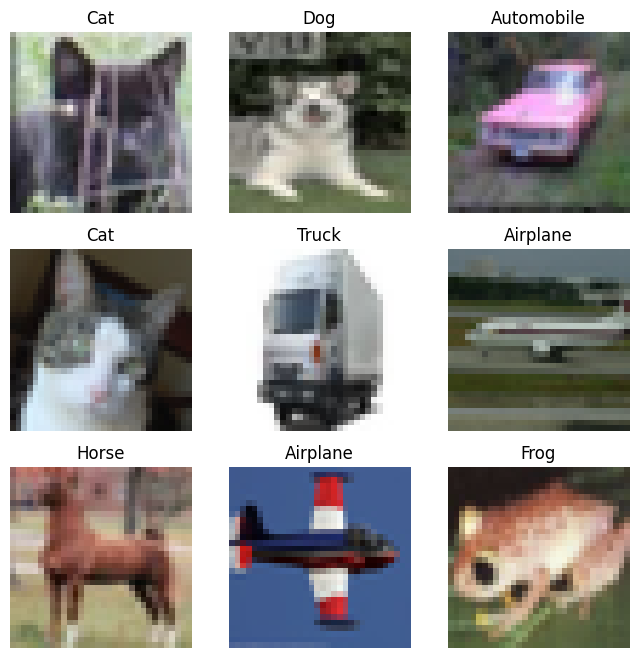

In [96]:
# Visualisation de quelques images du dataset
labels_map = {
    0: "Airplane",
    1: "Automobile",
    2: "Bird",
    3: "Cat",
    4: "Deer",
    5: "Dog",
    6: "Frog",
    7: "Horse",
    8: "Ship",
    9: "Truck",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(CIFAR10_train), size=(1,)).item()
    img, label = CIFAR10_train[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.permute(1, 2, 0))
plt.show()

Afin de simuler un contexte de faible quantité de données, nous réduisons le jeu d’entraînement. 

Cependant, pour garantir une évaluation fiable des performances, le jeu de test complet est conservé. La réduction est appliquée uniquement au jeu d’entraînement afin de simuler un régime de faible quantité de données.

In [95]:
# Réduction du dataset 
print("Taille du dataset d'entraînement complet :", len(CIFAR10_train))
print("Taille du dataset de test :", len(CIFAR10_test))

# Nombre de classes
num_classes = 10

# On récupère les labels des images d'entraînement
targets = np.array(CIFAR10_train.targets)

# On crée une liste regroupant les indices des images d'entraînement pour chaque classe
indices_par_class = [np.where(targets == i)[0] for i in range(num_classes)]

# Sous-échantillonnage : 100, 1000, 5000, 10000, 25000, 50000
n = [100, 1000, 5000, 10000, 25000, 50000]
train_subsets = {}
for taille in n:
    subset_indices = []
    for class_indices in indices_par_class:
        n = taille // num_classes
        selected = np.random.choice(class_indices, size=n, replace=False)
        subset_indices.extend(selected) # on concatène les indices sélectionnés pour chaque classe

    # On mélange les indices pour éviter d'avoir des classes regroupées
    np.random.shuffle(subset_indices)
    # Créer le subset d'entraînement à partir des indices sélectionnés
    train_subsets[taille] = torch.utils.data.Subset(CIFAR10_train, subset_indices)

print("Taille des nouveaux datasets d'entraînement")
for taille, subset in train_subsets.items():
    print(f"Subset {taille} : {len(subset)} images")


Taille du dataset d'entraînement complet : 50000
Taille du dataset de test : 10000
Taille des nouveaux datasets d'entraînement
Subset 100 : 100 images
Subset 1000 : 1000 images
Subset 5000 : 5000 images
Subset 10000 : 10000 images
Subset 25000 : 25000 images
Subset 50000 : 50000 images


On charge les datasets dans des DataLoaders. Cela permet de contrôler plus facilement la taille des batches, de réaliser un shuffle automatique entre chaque epoch à l'entraînement 

Ceci nous permettra également d'itérer directement sur les batches à l'entraînement. 

In [106]:
# Charger les datasets dans des DataLoaders
from torch.utils.data import DataLoader
batch_size = 250 # taille d'un batch

train_dataloaders = {}
for taille, train_subset in train_subsets.items():
    train_dataloaders[taille] = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)

test_dataloader = DataLoader(CIFAR10_test, batch_size=batch_size, shuffle=True, num_workers=2)

### Entraînement et comparaison des deux modèles 

Dans un premier temps, on tire les paramètres de *Powerful Design of Small Vision Transformer on CIFAR10 - Gent Wu (2025)* : 
- 100 epochs
- Taille de batch : 256
- On utilise l’optimiseur Adam avec un learning rate qui commence à 0,002, augmente progressivement pendant 10 epochs (warmup), puis décroît ensuite suivant une courbe cosinus. Le weight decay est fixé à 0,05.
- 12 têtes d'attention
- 9 blocs d'encodeur
- 64 patchs de taille 4x4

Mais selon la complexité de la tâche, on pourra les modifier afin d'alléger le temps de calcul. 

In [108]:
# Tous les paramètres
canal_couleur = 3 # nombre de canal couleur
taille_image = 32 # taille de l'image en pixels
patch_size = 4 # taille d'un patch en pixels
nb_patchs = (taille_image // patch_size) ** 2 # nombre total de patchs
embedding_dim = 144 # dimension d'un vecteur d'embedding
nb_classes = 10 # nombre de classes de la tâche de classification
nb_heads = 12 # nombre de têtes d'attention par couche d'attention
nb_transformer_blocks = 9 # nombre de blocs du Transformer 
hidden_layer_size = 4 * embedding_dim # nombre de neurones par couche du MLP
activation_function = torch.nn.GELU # fonction d'activation du MLP


In [123]:
# Instanciation du modèle Visual Transformer
model_Tiny_ViT = Tiny_Vit(
    canal_couleur=canal_couleur,
    embedding_dim=embedding_dim,
    patch_size=patch_size,
    nb_patchs=nb_patchs,
    nb_heads=nb_heads,
    hidden_layer_size=hidden_layer_size,
    activation_function=activation_function,
    num_transformer_blocks=nb_transformer_blocks,
    nb_classes=nb_classes
)

n_params = sum(p.numel() for p in model_Tiny_ViT.parameters() if p.requires_grad)
print(f"Nombre de paramètres entraînables : {n_params:,}")


Nombre de paramètres entraînables : 2,353,114


In [125]:
# Instanciation du modèle CNN
model_CNN = CNN(num_classes=num_classes, in_channels=canal_couleur)
n_params = sum(p.numel() for p in model_CNN.parameters() if p.requires_grad)
print(f"Nombre de paramètres entraînables : {n_params:,}")

Nombre de paramètres entraînables : 1,470,762


Afin de réaliser l'entraînement sur plusieurs tailles de datasets, on réinitialise le modèle pour chacune des tailles. On utilise la même graîne de générateur afin de repartir des mêmes coefficients. 

In [124]:
# Entraînement du ViT
epochs = 20 # Nombre d'epochs

ViT_results = {}
for taille, train_dataloader in train_dataloaders.items():

    torch.manual_seed(2215) 

    model_Tiny_ViT = Tiny_Vit(
    canal_couleur=canal_couleur,
    embedding_dim=embedding_dim,
    patch_size=patch_size,
    nb_patchs=nb_patchs,
    nb_heads=nb_heads,
    hidden_layer_size=hidden_layer_size,
    activation_function=activation_function,
    num_transformer_blocks=nb_transformer_blocks,
    nb_classes=nb_classes
    )

    start_time = time.time()
    ViT_results[taille] = train_model(model_Tiny_ViT,
                                      train_dataloader,
                                      test_dataloader,
                                      nb_classes=num_classes,
                                      epochs=epochs,
                                      lr=0.002,
                                      weight_decay=5e-2,
                                      affichage=False)
    end_time = time.time()
    print(f"Training du ViT sur le subset de taille {taille} terminé en {end_time - start_time:.2f} secondes.")
    ViT_results[taille]["training_time"] = end_time - start_time


c:\Users\nanou\anaconda3\envs\vit_cnn_projet_m2\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Training du ViT sur le subset de taille 100 terminé en 990.27 secondes.
Training du ViT sur le subset de taille 1000 terminé en 1203.47 secondes.
Training du ViT sur le subset de taille 5000 terminé en 2538.26 secondes.
Training du ViT sur le subset de taille 10000 terminé en 3114.48 secondes.
Training du ViT sur le subset de taille 25000 terminé en 7811.38 secondes.
Training du ViT sur le subset de taille 50000 terminé en 16069.73 secondes.


In [126]:
# Entraînement du CNN
epochs = 20 # Nombre d'epochs

CNN_results = {}
for taille, train_dataloader in train_dataloaders.items():

    torch.manual_seed(2215) 
    
    model_CNN = CNN(num_classes=num_classes, in_channels=canal_couleur)
    start_time = time.time()
    CNN_results[taille] = train_model(model_CNN,
                                      train_dataloader,
                                      test_dataloader,
                                      nb_classes=num_classes,
                                      epochs=epochs,
                                      lr=1e-3,
                                      weight_decay=1e-4,
                                      affichage=False)
    end_time = time.time()
    print(f"Training du CNN sur le subset de taille {taille} terminé en {end_time - start_time:.2f} secondes.")
    CNN_results[taille]["training_time"] = end_time - start_time

Training du CNN sur le subset de taille 100 terminé en 562.20 secondes.
Training du CNN sur le subset de taille 1000 terminé en 713.28 secondes.
Training du CNN sur le subset de taille 5000 terminé en 882.74 secondes.
Training du CNN sur le subset de taille 10000 terminé en 1151.57 secondes.
Training du CNN sur le subset de taille 25000 terminé en 1824.74 secondes.
Training du CNN sur le subset de taille 50000 terminé en 3256.48 secondes.


La cellule suivante apporte une légère correction à nos calculs de perte. En effet la fonction `torch.nn.CrossEntropyLoss`calcule une perte moyenne par batch, puis nous aditionnons toutes ces pertes dans notre Pipeline de training ($\sum_{epochs}\sum_{batch}\frac{1}{taille du batch}\sum_{i \in batch}loss_i$).

Il aurait fallut calculer une simple somme, au lieu d'une moyenne, à diviser par la taille totale du dataset. On approche cela en prenant $n_{dataset} \approx n_{batch} \times \#batches$ (qui n'est pas tout à fait juste car la taille de chaque batch n'est pas forcément constante, ni égale à ce qu'on a fixé plus haut) ce qui revient à diviser notre perte actuelle par le nombre de batches. 

In [133]:
# Correction de la loss de training : on divise la loss totale par le nombre de batches pour obtenir 
# ~une loss moyenne par batch et par epoch, ce qui est plus comparable entre les différentes tailles 
# de subsets
for taille in ViT_results:
    n_batches = len(train_dataloaders[taille])

    ViT_results[taille]["corrected_train_loss"] = [
        l / n_batches for l in ViT_results[taille]["train_loss"]
    ]
    CNN_results[taille]["corrected_train_loss"] = [
        l / n_batches for l in CNN_results[taille]["train_loss"]
    ]

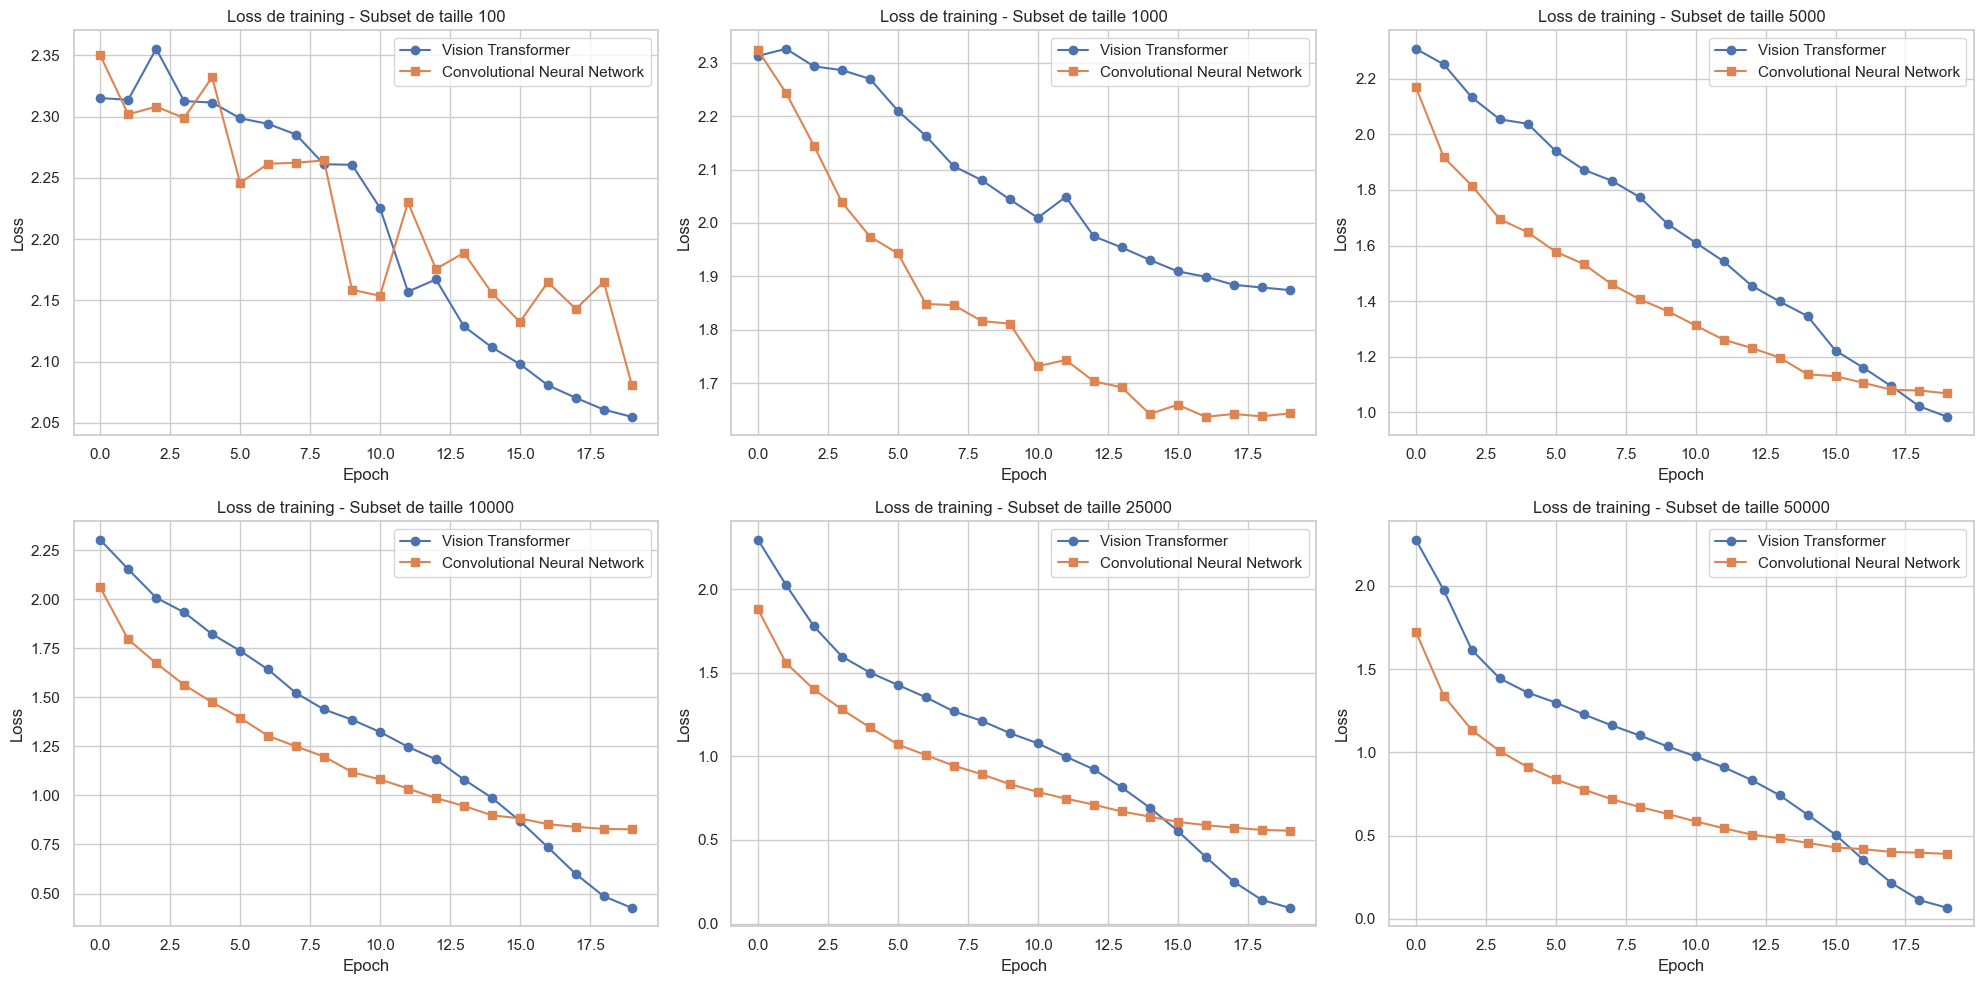

In [134]:
# Comparaison et visualisation des résultats

# courbes de loss
sns.set_theme(style="whitegrid")
fig, axes =plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes = axes.flatten()
for taille, ax in zip(ViT_results.keys(), axes):
    plot_loss(
        ViT_results[taille]["corrected_train_loss"],
        CNN_results[taille]["corrected_train_loss"],
        ax=ax
    )
    ax.set_title(f"Loss de training - Subset de taille {taille}")

plt.tight_layout()
plt.show()

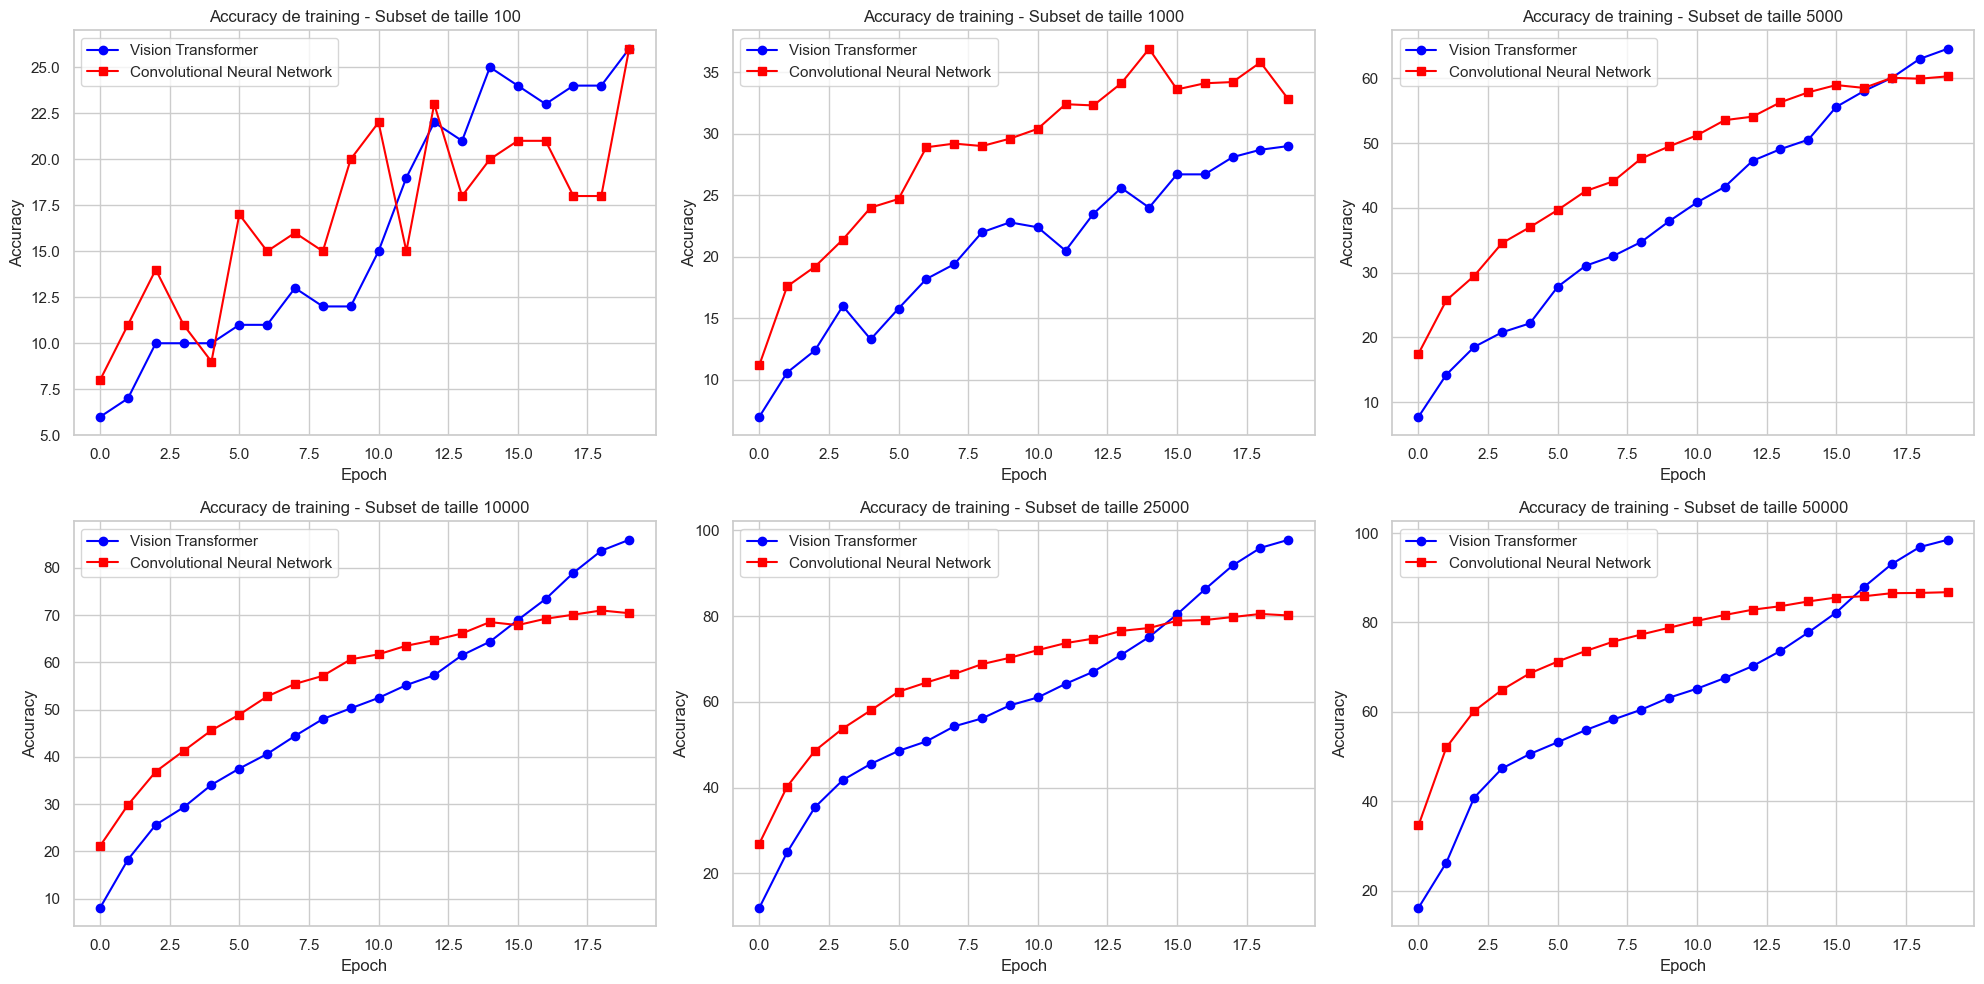

In [138]:
# courbes d'accuracy de training
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes = axes.flatten()
for taille, ax in zip(ViT_results.keys(), axes):
    plot_accuracy(
        ViT_results[taille]["train_acc"],
        CNN_results[taille]["train_acc"],
        ax=ax
    )
    ax.set_title(f"Accuracy de training - Subset de taille {taille}")

plt.tight_layout()
plt.show()

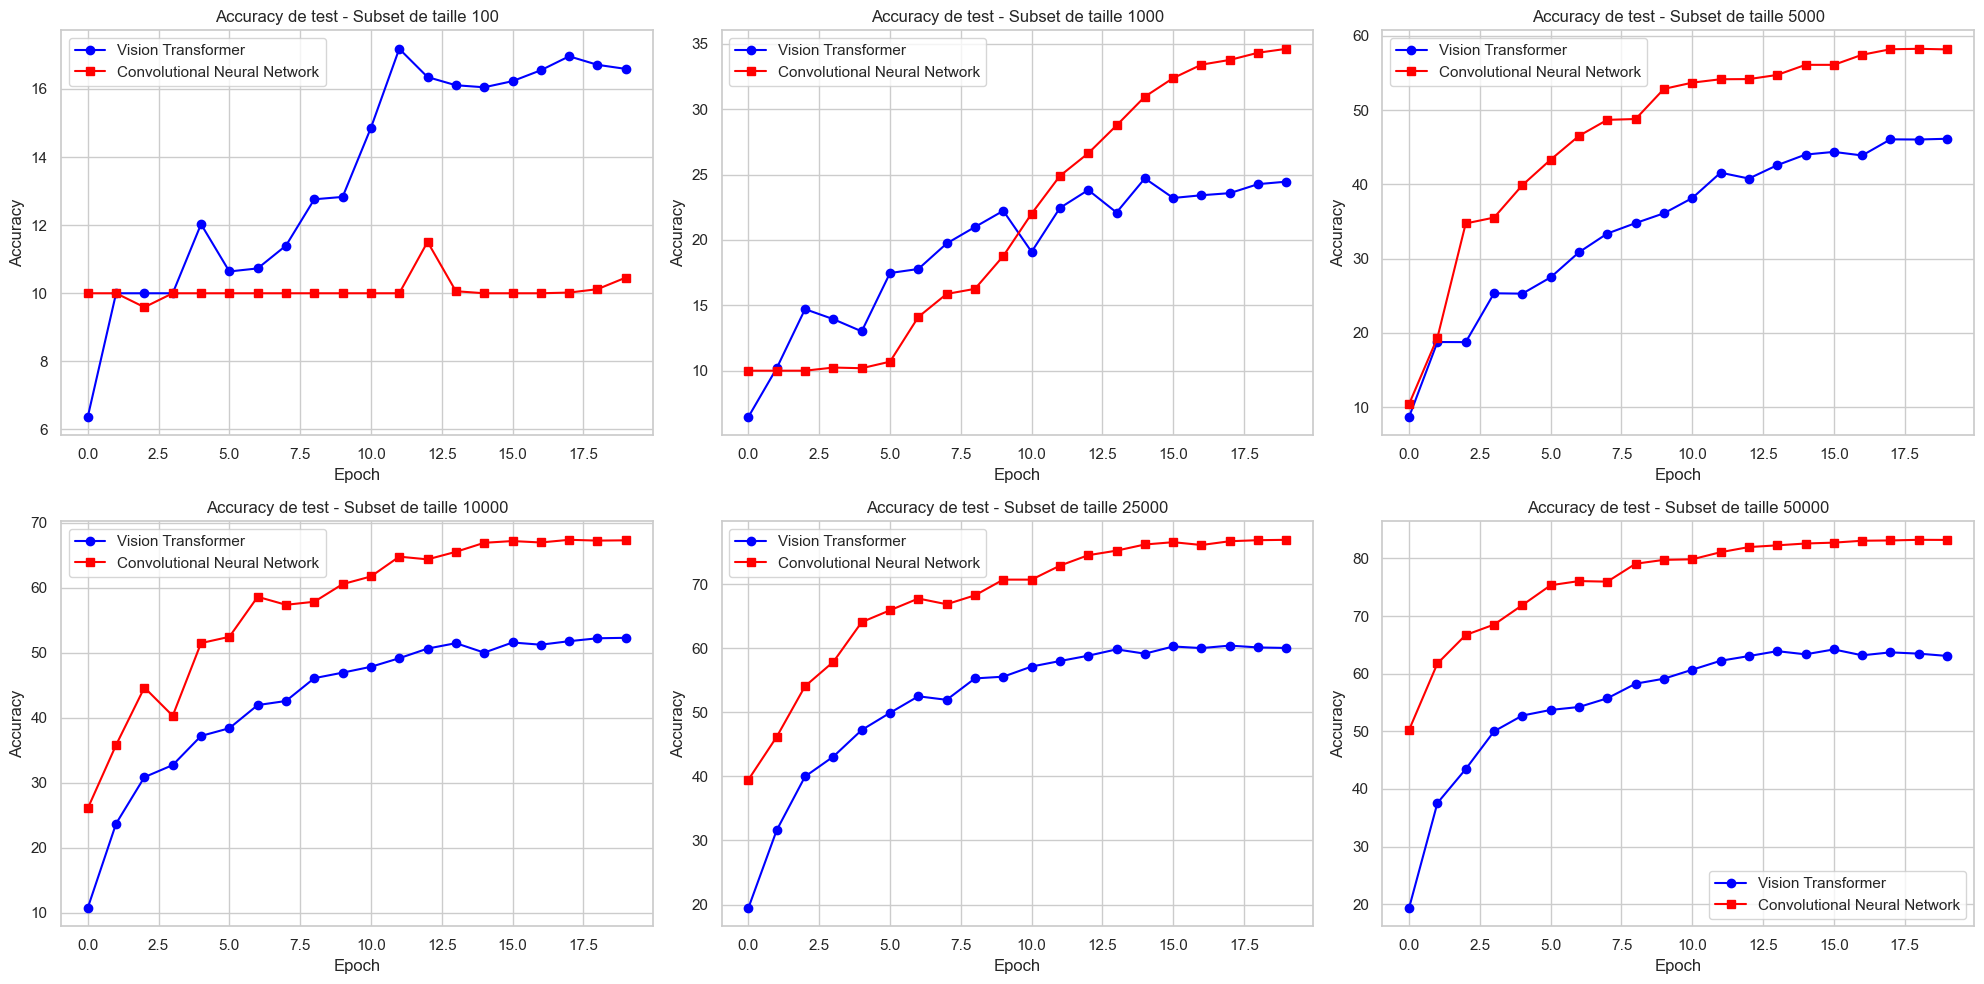

In [140]:
# courbes d'accuracy de test / capacité de généralisation
sns.set_theme(style="whitegrid")
fig, axes =plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes = axes.flatten()
for taille, ax in zip(ViT_results.keys(), axes):
    plot_accuracy(
        ViT_results[taille]["val_acc"],
        CNN_results[taille]["val_acc"],
        ax=ax
    )
    ax.set_title(f"Accuracy de test - Subset de taille {taille}")

plt.tight_layout()
plt.show()

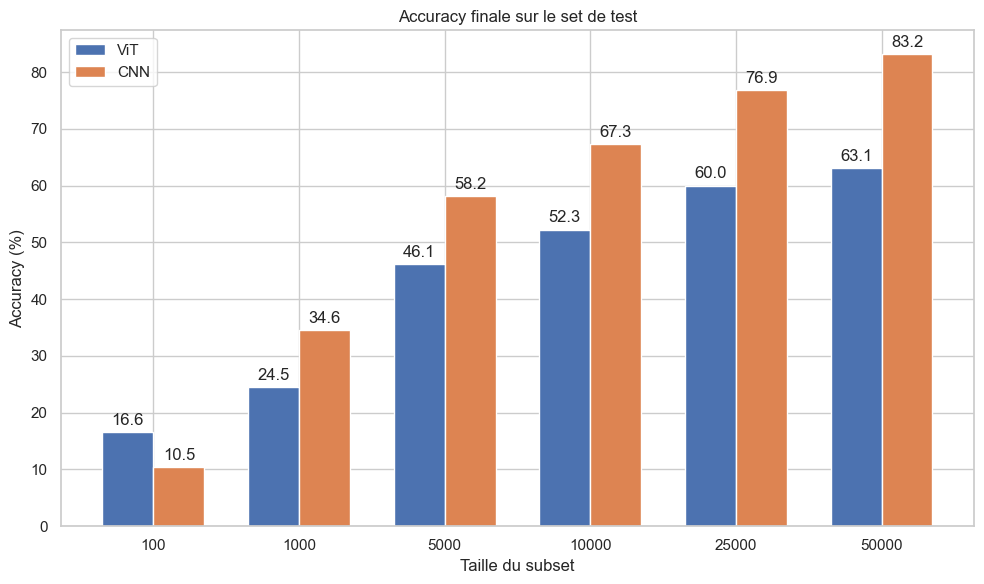

In [143]:
# évaluation finale
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
etiquettes = [str(taille) for taille in ViT_results.keys()]
x = np.arange(len(etiquettes))
width = 0.35

valeurs_ViT = [ViT_results[taille]["val_acc"][-1] for taille in ViT_results.keys()]
valeurs_CNN = [CNN_results[taille]["val_acc"][-1] for taille in CNN_results.keys()]

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, valeurs_ViT, width, label="ViT")
rects2 = ax.bar(x + width/2, valeurs_CNN, width, label="CNN")

ax.set_title("Accuracy finale sur le set de test")
ax.set_xlabel("Taille du subset")
ax.set_ylabel("Accuracy (%)")
ax.set_xticks(x)
ax.set_xticklabels(etiquettes)
ax.legend()

# Valeurs sur les barres
ax.bar_label(rects1, padding=3, fmt="%.1f")
ax.bar_label(rects2, padding=3, fmt="%.1f")

plt.tight_layout()
plt.show()

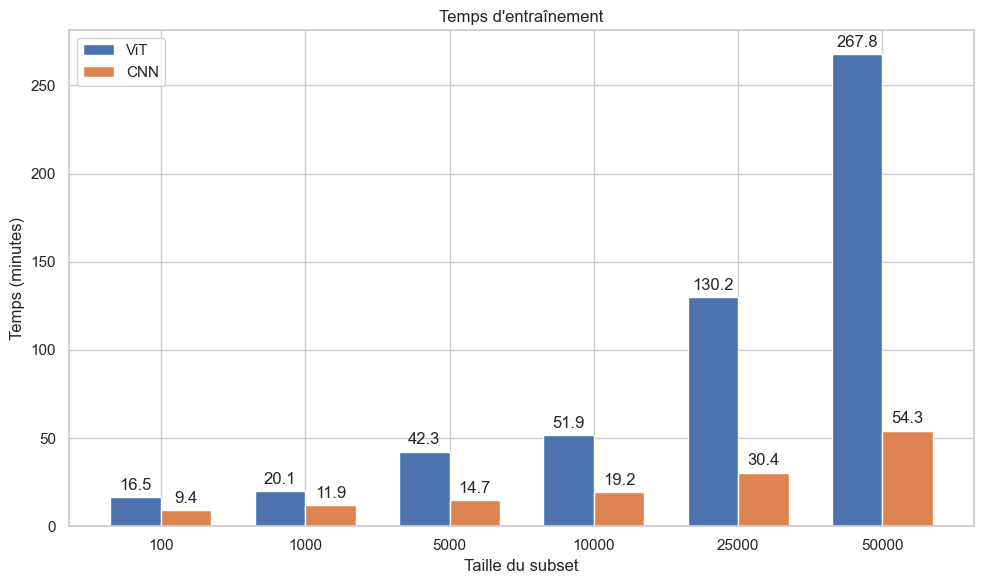

In [145]:
# Récupération des temps d'entraînement
temps_ViT = [np.array(ViT_results[taille]["training_time"])/60 for taille in ViT_results.keys()]
temps_CNN = [np.array(CNN_results[taille]["training_time"])/60 for taille in CNN_results.keys()]

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, temps_ViT, width, label="ViT")
rects2 = ax.bar(x + width/2, temps_CNN, width, label="CNN")

ax.set_title("Temps d'entraînement")
ax.set_xlabel("Taille du subset")
ax.set_ylabel("Temps (minutes)")
ax.set_xticks(x)
ax.set_xticklabels(etiquettes)
ax.legend()

ax.bar_label(rects1, padding=3, fmt="%.1f")
ax.bar_label(rects2, padding=3, fmt="%.1f")

plt.tight_layout()
plt.show()

## Expérimentation sur les textures Locales 

*Un CNN applique des **filtres convolutifs locaux** qui détectent de manière naturelle des patterns répétitifs (bords, orientations, fréquences).*
  
*Un ViT sans ce biais doit découvrir ces structures par attention, ce qui nécessite beaucoup plus d'exemples.*

Ce dataset contient **6 classes de textures** :
- `0` : Lignes horizontales
- `1` : Lignes verticales  
- `2` : Damier
- `3` : Lignes diagonales
- `4` : Cercles concentriques
- `5` : Rayons (pattern radial)

Chaque image est **32×32 en RGB** (3 canaux) avec colorisation aléatoire pour rendre la tâche plus difficile et réaliste.

In [242]:
# Fonctions de génération de textures

def horizontal_lines(size=32):
    """Lignes horizontales espacées."""
    img = np.zeros((size, size))
    for i in range(0, size, 6):
        img[i:i+2, :] = 1
    return img

def vertical_lines(size=32):
    """Lignes verticales espacées."""
    img = np.zeros((size, size))
    for i in range(0, size, 6):
        img[:, i:i+2] = 1
    return img

def checkerboard(size=32, block=4):
    """Damier avec blocs de taille variable."""
    r = np.arange(size) // block
    c = np.arange(size) // block
    return ((r[:, None] + c[None, :]) % 2).astype(float)

def diagonal_lines(size=32):
    img = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            if (i + j) % 8 < 3:
                img[i, j] = 1
    return img

def diagonal_lines(size=32):
    """Lignes diagonales de fréquences aléatoires."""
    freq = nprng.choice([3, 4, 5, 6])   # fréquence aléatoire
    img = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            if (i + j) % freq < freq // 2:
                img[i, j] = 1
    return img

def concentric_circles(size=32):
    """Cercles concentriques depuis le centre."""
    cx, cy = size // 2, size // 2
    img = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            d = int(math.sqrt((i - cx)**2 + (j - cy)**2))
            img[i, j] = 1 if d % 5 < 2 else 0
    return img

def radial_pattern(size=32):
    """Secteurs alternés depuis le centre (pattern radial)."""
    cx, cy = size // 2, size // 2
    img = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            angle = math.atan2(i - cy, j - cx)
            img[i, j] = int((angle + math.pi) / (math.pi / 4)) % 2
    return img

In [243]:
texture_generators = [
    horizontal_lines,
    vertical_lines,
    checkerboard,
    diagonal_lines,
    concentric_circles,
    radial_pattern,
]

texture_names = [
    "Lignes H", "Lignes V", "Damier",
    "Diagonales", "Cercles", "Rayons"
]

num_classes_texture = len(texture_generators)

In [244]:
def colorize(base_img, rng=None):
    """
    La fonction Colorize se concentre sur une texture en niveaux de gris [0,1], c'est-à-dire d'une image RGB [0,1].
    J'ai choisi deux couleurs aléatoires : une pour le fond et une autre pour le motif.
    Ce qui rend la tâche plus dure est que le modèle ne peut pas utiliser la couleur comme raccourci.
    """
    if rng is None:
        rng = np.random.default_rng()

    fg_color = rng.uniform(0.3, 1.0, size=(3,))
    bg_color = rng.uniform(0.0, 0.5, size=(3,))

    img_rgb = np.zeros((3, base_img.shape[0], base_img.shape[1]), dtype=np.float32)
    for c in range(3):
        img_rgb[c] = base_img * fg_color[c] + (1 - base_img) * bg_color[c]

    # Bruit gaussien léger
    noise = rng.normal(0, 0.06, img_rgb.shape).astype(np.float32)
    img_rgb = np.clip(img_rgb + noise, 0, 1)
    return img_rgb

In [245]:
class TextureDataset(torch.utils.data.Dataset):
    """
    Dataset de textures synthétiques RGB 32×32.
    Les classes sont équilibrées, on a une colorisation et le bruit qui sont aléatoires par image.
    """
    def __init__(self, n_samples=6000, seed=0):
        rng = np.random.default_rng(seed)
        images, labels = [], []

        n_per_class = n_samples // num_classes_texture
        for cls_idx, gen_fn in enumerate(texture_generators):
            for _ in range(n_per_class):
                base = gen_fn()
                img = colorize(base, rng=rng)
                images.append(img)
                labels.append(cls_idx)

        # Mélange reproductible
        perm = rng.permutation(len(images))
        self.images = np.array(images)[perm]
        self.labels = np.array(labels)[perm]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.images[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

In [246]:
# Création des datasets
train_texture = TextureDataset(n_samples=6000, seed=42)
test_texture  = TextureDataset(n_samples=1200, seed=99)

train_loader_texture = DataLoader(train_texture, batch_size=64, shuffle=True,  num_workers=0)
test_loader_texture  = DataLoader(test_texture,  batch_size=64, shuffle=False, num_workers=0)

print(f"Train : {len(train_texture)} images VS Test : {len(test_texture)} images")
print(f"Format d'une image : {train_texture[0][0].shape}  →  3 canaux RGB, 32×32 px")

Train : 6000 images VS Test : 1200 images
Format d'une image : torch.Size([3, 32, 32])  →  3 canaux RGB, 32×32 px


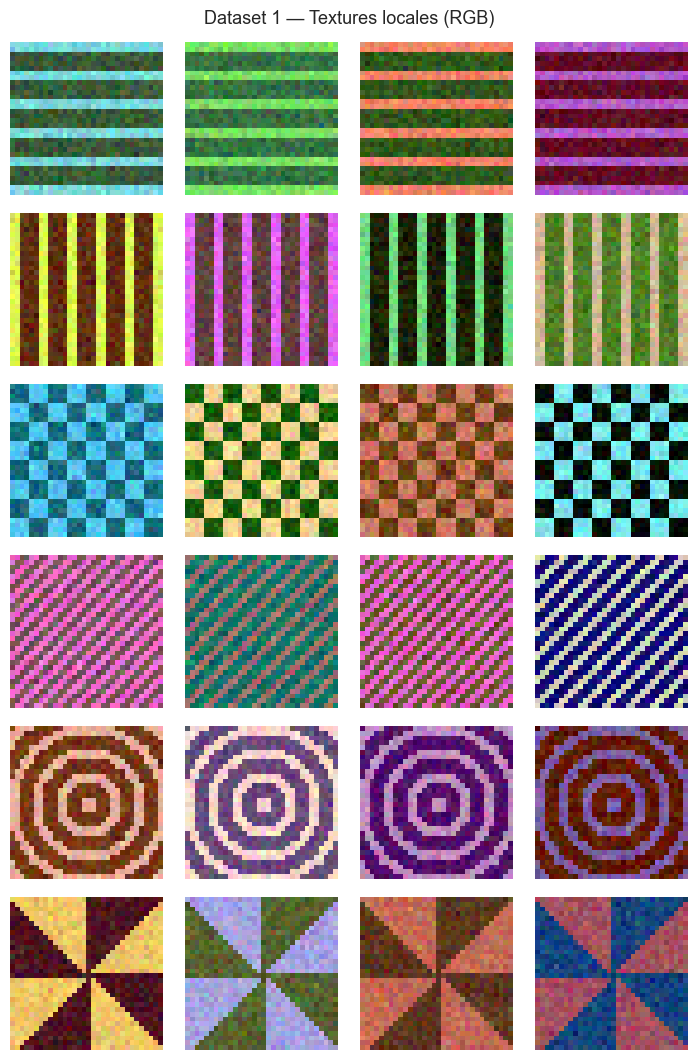

In [247]:
def show_dataset_samples(dataset, class_names, n_per_class=4, title="Exemples du dataset"):
    """Affiche n_per_class exemples pour chaque classe."""
    n_classes = len(class_names)
    fig, axes = plt.subplots(n_classes, n_per_class, figsize=(n_per_class * 1.8, n_classes * 1.8))
    fig.suptitle(title, fontsize=13)

    # Index des images par classe
    class_indices = {c: [] for c in range(n_classes)}
    for i in range(len(dataset)):
        _, lbl = dataset[i]
        cls = lbl.item() if hasattr(lbl, 'item') else int(lbl)
        if len(class_indices[cls]) < n_per_class:
            class_indices[cls].append(i)
        if all(len(v) == n_per_class for v in class_indices.values()):
            break

    for r, cls in enumerate(range(n_classes)):
        for c, idx in enumerate(class_indices[cls]):
            img, _ = dataset[idx]
            ax = axes[r, c]
            ax.imshow(img.permute(1, 2, 0).numpy())
            ax.axis("off")
            if c == 0:
                ax.set_ylabel(class_names[cls], fontsize=9, rotation=0,
                              labelpad=55, va='center')

    plt.tight_layout()
    plt.show()

show_dataset_samples(train_texture, texture_names, title="Dataset 1 — Textures locales (RGB)")

In [248]:
epochs = 15 # Nombre d'epochs

# Entraînement du CNN
cnn_texture = CNN(num_classes=num_classes_texture, in_channels=canal_couleur)

print("=== Entraînement CNN — Dataset Textures ===")

start_time = time.time()
CNN_results = train_model(cnn_texture, 
                          train_loader_texture, 
                          test_loader_texture, 
                          nb_classes=num_classes, 
                          epochs=epochs, 
                          lr=1e-3, 
                          weight_decay=1e-4)
end_time = time.time()
CNN_training_time = end_time - start_time

=== Entraînement CNN — Dataset Textures ===
Epoch 0 | Loss: 35.99 | Train Acc: 86.083% | Val Acc: 98.917%
Epoch 1 | Loss: 3.04 | Train Acc: 98.983% | Val Acc: 98.750%
Epoch 2 | Loss: 2.07 | Train Acc: 99.483% | Val Acc: 99.750%
Epoch 3 | Loss: 1.36 | Train Acc: 99.650% | Val Acc: 99.833%
Epoch 4 | Loss: 0.67 | Train Acc: 99.800% | Val Acc: 99.833%
Epoch 5 | Loss: 0.80 | Train Acc: 99.700% | Val Acc: 99.750%
Epoch 6 | Loss: 0.50 | Train Acc: 99.833% | Val Acc: 99.917%
Epoch 7 | Loss: 0.92 | Train Acc: 99.817% | Val Acc: 99.917%
Epoch 8 | Loss: 0.35 | Train Acc: 99.900% | Val Acc: 99.833%
Epoch 9 | Loss: 0.24 | Train Acc: 99.933% | Val Acc: 99.833%
Epoch 10 | Loss: 0.36 | Train Acc: 99.883% | Val Acc: 99.750%
Epoch 11 | Loss: 0.22 | Train Acc: 99.917% | Val Acc: 99.833%
Epoch 12 | Loss: 0.20 | Train Acc: 99.967% | Val Acc: 99.833%
Epoch 13 | Loss: 0.26 | Train Acc: 99.917% | Val Acc: 99.833%
Epoch 14 | Loss: 0.16 | Train Acc: 99.967% | Val Acc: 99.833%


In [249]:
# Entraînement du Visual Transformer
model_Tiny_ViT_texture = Tiny_Vit(
    canal_couleur=canal_couleur,
    embedding_dim=embedding_dim,
    patch_size=patch_size,
    nb_patchs=nb_patchs,
    nb_heads=nb_heads,
    hidden_layer_size=hidden_layer_size,
    activation_function=activation_function,
    num_transformer_blocks=nb_transformer_blocks,
    nb_classes=num_classes_texture
)

print("=== Entraînement ViT — Dataset Textures ===")
start_time = time.time()
ViT_results_texture = train_model(model_Tiny_ViT_texture, 
                          train_loader_texture, 
                          test_loader_texture, 
                          nb_classes=num_classes_texture, 
                          epochs=epochs, 
                          lr=0.002, 
                          weight_decay=5e-2)
end_time = time.time()
ViT_training_time_texture = end_time - start_time

=== Entraînement ViT — Dataset Textures ===
Epoch 0 | Loss: 168.10 | Train Acc: 21.533% | Val Acc: 29.333%
Epoch 1 | Loss: 97.32 | Train Acc: 58.250% | Val Acc: 94.583%
Epoch 2 | Loss: 14.27 | Train Acc: 95.733% | Val Acc: 98.750%
Epoch 3 | Loss: 10.51 | Train Acc: 97.017% | Val Acc: 98.833%


c:\Users\nanou\anaconda3\envs\vit_cnn_projet_m2\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 4 | Loss: 3.38 | Train Acc: 99.117% | Val Acc: 99.250%
Epoch 5 | Loss: 4.13 | Train Acc: 98.883% | Val Acc: 99.083%
Epoch 6 | Loss: 3.98 | Train Acc: 99.017% | Val Acc: 99.917%
Epoch 7 | Loss: 1.08 | Train Acc: 99.667% | Val Acc: 99.417%
Epoch 8 | Loss: 1.44 | Train Acc: 99.483% | Val Acc: 99.583%
Epoch 9 | Loss: 0.76 | Train Acc: 99.750% | Val Acc: 99.917%
Epoch 10 | Loss: 0.74 | Train Acc: 99.800% | Val Acc: 99.583%
Epoch 11 | Loss: 0.68 | Train Acc: 99.783% | Val Acc: 99.917%
Epoch 12 | Loss: 0.69 | Train Acc: 99.733% | Val Acc: 99.750%
Epoch 13 | Loss: 0.52 | Train Acc: 99.783% | Val Acc: 99.917%
Epoch 14 | Loss: 0.40 | Train Acc: 99.850% | Val Acc: 99.917%


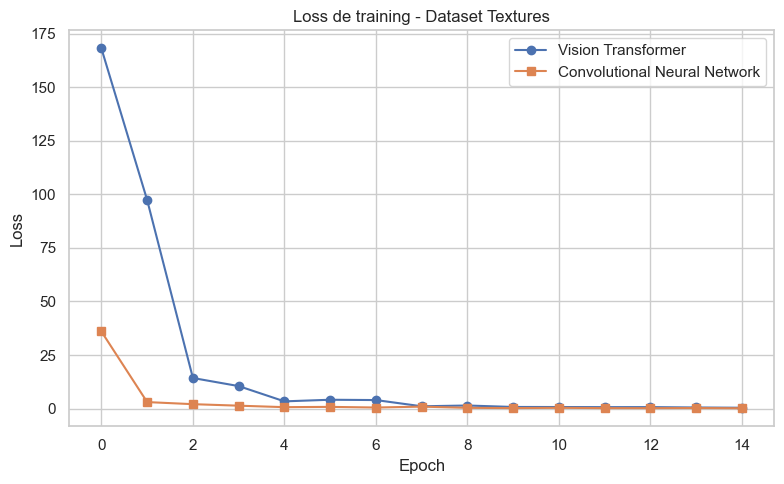

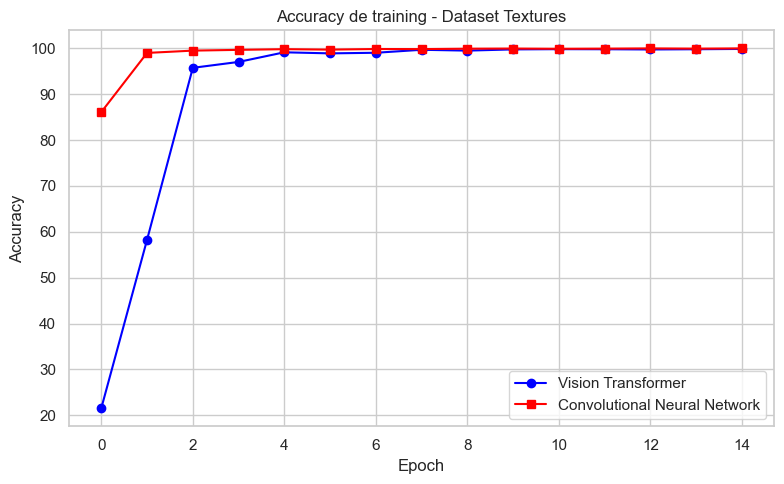

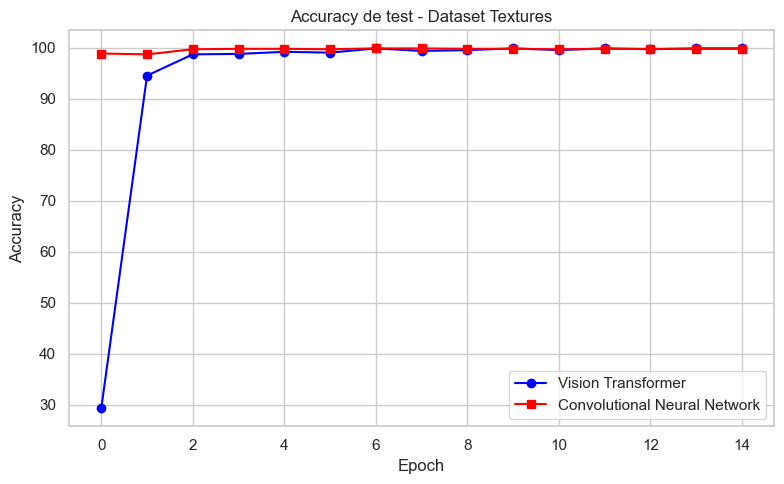

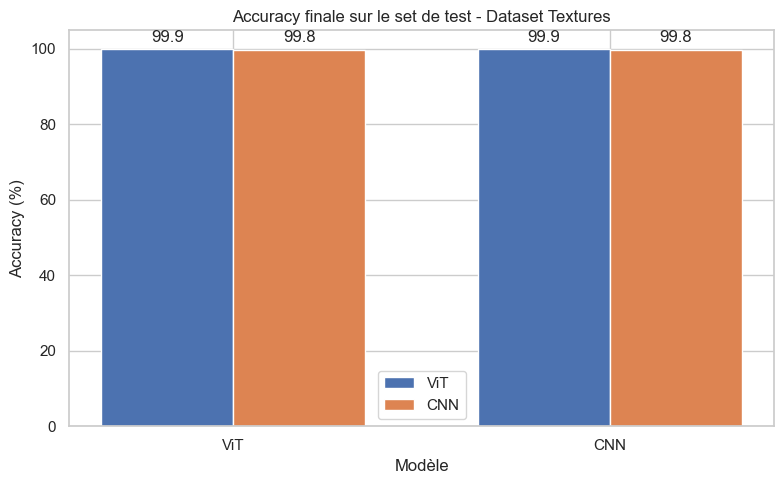

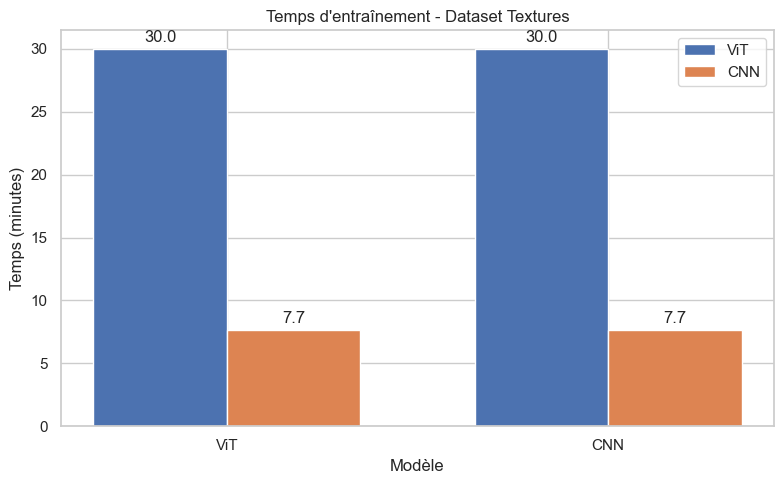

In [250]:
# Comparaison et visualisation des résultats

# courbes de loss
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))
plot_loss(
    ViT_results_texture["train_loss"],
    CNN_results["train_loss"],
    ax=ax
)
ax.set_title("Loss de training - Dataset Textures")
plt.tight_layout()
plt.show()

# courbes d'accuracy de training
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))
plot_accuracy(
    ViT_results_texture["train_acc"],
    CNN_results["train_acc"],
    ax=ax
)
ax.set_title("Accuracy de training - Dataset Textures")
plt.tight_layout()
plt.show()  

# courbes d'accuracy de test / capacité de généralisation
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))
plot_accuracy(
    ViT_results_texture["val_acc"],
    CNN_results["val_acc"],
    ax=ax
)
ax.set_title("Accuracy de test - Dataset Textures")
plt.tight_layout()
plt.show()

# évaluation finale  
sns.set_theme(style="whitegrid")
etiquettes = ["ViT", "CNN"]
x = np.arange(len(etiquettes))
width = 0.35
valeurs_ViT = ViT_results_texture["val_acc"][-1]
valeurs_CNN = CNN_results["val_acc"][-1]
fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, [valeurs_ViT], width, label="ViT")
rects2 = ax.bar(x + width/2, [valeurs_CNN], width, label="CNN")
ax.set_title("Accuracy finale sur le set de test - Dataset Textures")
ax.set_xlabel("Modèle")
ax.set_ylabel("Accuracy (%)")
ax.set_xticks(x)
ax.set_xticklabels(etiquettes)
ax.legend()
ax.bar_label(rects1, padding=3, fmt="%.1f")
ax.bar_label(rects2, padding=3, fmt="%.1f")
plt.tight_layout()
plt.show()

# Récupération des temps d'entraînement
temps_ViT = ViT_training_time_texture / 60
temps_CNN = CNN_training_time / 60
fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, [temps_ViT], width, label="ViT")
rects2 = ax.bar(x + width/2, [temps_CNN], width, label="CNN")
ax.set_title("Temps d'entraînement - Dataset Textures")
ax.set_xlabel("Modèle")
ax.set_ylabel("Temps (minutes)")
ax.set_xticks(x)
ax.set_xticklabels(etiquettes)
ax.legend()
ax.bar_label(rects1, padding=3, fmt="%.1f")
ax.bar_label(rects2, padding=3, fmt="%.1f")
plt.tight_layout()
plt.show() 



## Expérimentation sur les relations spatiales 2D (dessus / dessous / gauche / droite)

Dans cette section, l'objectif est de montrer que les CNN exploitent mieux la structure spatiale locale. 

Le jeu de données est constitué d'image regroupant plusieurs formes géométriques : 
- Une forme cible = un cercle de n’importe quelle couleur, n’importe quelle taille
- Une forme de référence = forme de couleur rouge
- D’autres formes de position, taille, rotation et couleur choisies aléatoirement (sauf le cercle et pas de couleur rouge)

Les images sont classifiées selon la position de la forme de référence par rapport à la forme cible. Par exemple le label "droite" veut dire que le cercle est à droite de la forme cible rouge. 

Dans la section suivante, on définit différentes fonctions permettant de générer notre dataset : 
- `random_color_no_red`: génère aléatoirement une couleur autre que le rouge
- `red_color`: génère une couleur rouge
- `circle`, `square`, `triangle`, `polygon`: permet de dessiner sur une image divers types de formes géométriques
- `shape_dict`, `relation_dict`: ce sont deux dictionnaires qui permettront de choisir aléatoirement la classe de l'image (droite, gauche, haut, bas) et les formes géométriques qu'elle contient. 
- `make_class`: dessine la forme rouge et le cercle selon un label donné
- `draw_picture`: utilise les fonctions précédentes pour générer aléatoirement un élément du dataset. 

In [181]:
def random_color_no_red():
    r = torch.randint(0,80,(1,))      # rouge faible
    g = torch.randint(80,256,(1,))
    b = torch.randint(80,256,(1,))
    return torch.tensor([r.item(), g.item(), b.item()], dtype=torch.float32).view(3,1)

def red_color():
    return torch.tensor([[255.0],[0.0],[0.0]])

def circle(img, yy, xx, color_func = random_color_no_red):

    _, h, w = img.shape
    
    x = torch.randint(0, w, (1,), generator=rng)
    y = torch.randint(0, h, (1,), generator=rng)
    r = torch.randint(5, 50, (1,), generator=rng)

    color = color_func()

    mask = (xx-x)**2 + (yy-y)**2 <= r**2

    alpha = torch.rand(1).item()*0.5 + 0.3
    img[:, mask] = alpha * color + (1 - alpha) * img[:, mask]

    return img, mask

def square(img, yy, xx, color_func = random_color_no_red):

    _, h, w = img.shape
    
    x = torch.randint(0, w-10, (1,), generator=rng)
    y = torch.randint(0, h-10, (1,), generator=rng)
    size = torch.randint(3, 70, (1,), generator=rng)

    color = color_func()

    mask = (xx-x) * (xx-x-size) <= 0
    mask = mask & ((yy-y) * (yy-y-size) <= 0)

    alpha = torch.rand(1).item()*0.5 + 0.3
    img[:, mask] = alpha * color + (1 - alpha) * img[:, mask]

    return img, mask

def triangle(img, yy, xx, color_func = random_color_no_red, r_min=6, r_max=50):

    _, h, w = img.shape

    # rayon du triangle
    r = torch.randint(r_min, r_max, (1,), generator=rng).item()

    # centre choisi pour que le triangle reste dans l'image
    cx = torch.randint(r, w-r, (1,), generator=rng).item()
    cy = torch.randint(r, h-r, (1,), generator=rng).item()

    # rotation aléatoire
    theta = torch.rand(1, generator=rng).item() * 2*math.pi

    # sommets du triangle
    xs = []
    ys = []

    for i in range(3):
        angle = theta + i * 2*math.pi/3
        x = cx + r * math.cos(angle)
        y = cy + r * math.sin(angle)
        xs.append(int(x))
        ys.append(int(y))

    x = torch.tensor(xs)
    y = torch.tensor(ys)

    def edge(x1,y1,x2,y2,x,y):
        return (x-x1)*(y2-y1) - (y-y1)*(x2-x1)

    b1 = edge(x[0],y[0],x[1],y[1],xx,yy) >= 0
    b2 = edge(x[1],y[1],x[2],y[2],xx,yy) >= 0
    b3 = edge(x[2],y[2],x[0],y[0],xx,yy) >= 0

    mask = (b1 & b2 & b3) | (~b1 & ~b2 & ~b3)

    color = color_func()
    alpha = torch.rand(1).item()*0.5 + 0.3
    img[:, mask] = alpha * color + (1 - alpha) * img[:, mask]
    return img, mask

def polygon(img, yy, xx, color_func = random_color_no_red, n_min=5, n_max=7, r_min=6, r_max=50):

    _, h, w = img.shape

    n = torch.randint(n_min, n_max+1, (1,), generator=rng).item()
    r = torch.randint(r_min, r_max, (1,), generator=rng).item()

    cx = torch.randint(r, w-r, (1,), generator=rng).item()
    cy = torch.randint(r, h-r, (1,), generator=rng).item()

    theta = torch.rand(1, generator=rng).item() * 2*math.pi

    xs = []
    ys = []

    for i in range(n):
        angle = theta + i * 2*math.pi/n
        xs.append(cx + r * math.cos(angle))
        ys.append(cy + r * math.sin(angle))

    x = torch.tensor(xs)
    y = torch.tensor(ys)

    mask_pos = torch.ones_like(xx, dtype=torch.bool)
    mask_neg = torch.ones_like(xx, dtype=torch.bool)

    for i in range(n):

        x1, y1 = x[i], y[i]
        x2, y2 = x[(i+1) % n], y[(i+1) % n]

        edge = (xx-x1)*(y2-y1) - (yy-y1)*(x2-x1)

        mask_pos &= edge >= 0
        mask_neg &= edge <= 0

    mask = mask_pos | mask_neg

    color = color_func()
    alpha = torch.rand(1).item()*0.5 + 0.3
    img[:, mask] = alpha * color + (1 - alpha) * img[:, mask]

    return img, mask

shape_dict = {
    0: square,
    1: triangle,
    2: polygon}

relation_dict = {
    0: "gauche",
    1: "droite",
    2: "haut",
    3: "bas"}

def safe_randint(a, b, size = (1,), generator=rng):
    a = int(a)
    b = int(b)
    if a >= b:
        return torch.tensor([a])
    return torch.randint(a, b, size, generator=generator)

def make_class(img, yy, xx, relation, shape_dict = shape_dict):
    _, h, w = img.shape

    # Forme "cible" rouge 
    target_shape = torch.randint(0, len(shape_dict), (1,), generator=rng).item()
    img, target_mask = shape_dict[target_shape](img, yy, xx, color_func=red_color)

    # Calcul des coordonnées du carré englobant la forme cible
    min_x = torch.argmax((torch.sum(target_mask, axis=0)!=0).to(torch.long)) # plus petit x qui contient un pixel du cercle
    max_y = torch.argmax((torch.sum(target_mask, axis=1)!=0).to(torch.long)) # plus haut y qui contient un pixel du cercle

    max_x = min_x + torch.sum((torch.sum(target_mask, axis=0)!=0).to(torch.long)) - 1 # plus grand x qui contient un pixel du cercle
    min_y = max_y + torch.sum((torch.sum(target_mask, axis=1)!=0).to(torch.long)) - 1 # plus bas y qui contient un pixel du cercle

    # Cercle de référence : choisir le centre à une distance d du carré englobant la forme cible, dans la direction indiquée par "relation"
    r = torch.randint(5, 50, (1,), generator=rng)
    padding = r.item()
    if relation == "gauche":
        y = torch.randint(max_y, min_y, (1,), generator=rng)
        x = safe_randint(0, min_x-padding, (1,), generator=rng)
    if relation == "droite":
        y = torch.randint(max_y, min_y, (1,), generator=rng)
        x = safe_randint(max_x+padding, w, (1,), generator=rng)
    if relation == "haut":
        x = torch.randint(min_x, max_x, (1,), generator=rng)
        y = safe_randint(0, max_y-padding, (1,), generator=rng)
    if relation == "bas":
        x = torch.randint(min_x, max_x, (1,), generator=rng)
        y = safe_randint(min_y+padding, h, (1,), generator=rng)
    
    color = random_color_no_red()

    mask = (xx-x)**2 + (yy-y)**2 <= r**2

    alpha = torch.rand(1).item()*0.5 + 0.3
    img[:, mask] = alpha * color + (1 - alpha) * img[:, mask]
    return img

def draw_picture(shape_dict = shape_dict, relation_dict = relation_dict):
    # Créer une image blanche de taille 240x240 pixels avec 3 canaux de couleur (RGB)
    img = torch.ones((3,224,224))*255
    _, h, w = img.shape
    yy, xx = torch.meshgrid(torch.arange(h), torch.arange(w), indexing="ij")


    # Sélectionner le nombre de formes supplémentaires à dessiner
    n_shapes = torch.randint(3, 10, (1,), generator=rng).item()
    # Sélectionner aléatoirement les formes supplémentairesà dessiner
    shapes = torch.randint(0, len(shape_dict), (n_shapes,), generator=rng)
    for shape in shapes :
        img, _ = shape_dict[int(shape)](img, yy, xx)

    # Créer la classe de l'image 
        # Choisir aléatoirement une relation
    label = torch.randint(0, len(relation_dict), (1,), generator=rng).item()
    relation_str = relation_dict[label]
    img = make_class(img, yy, xx, relation_str, shape_dict=shape_dict)
    return img, relation_str, label


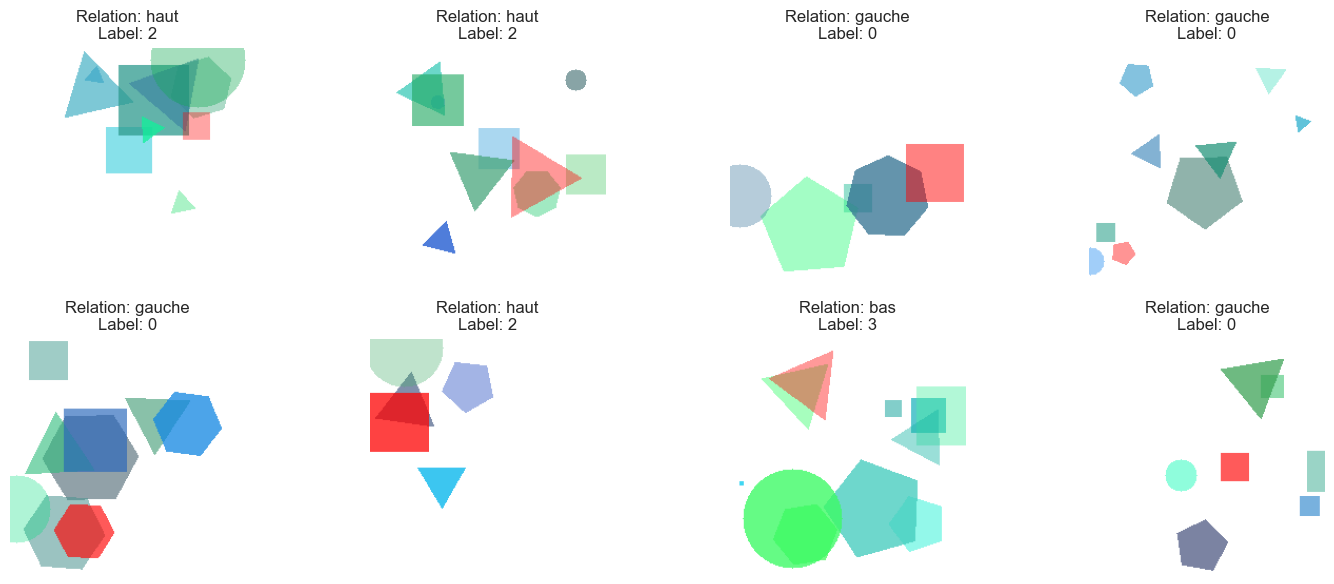

In [184]:
# Illustration de quelques images du dataset

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for i in range(8):
    img, relation, label = draw_picture()
    ax = axes[i//4, i%4]
    ax.imshow(img.permute(1,2,0).int())
    ax.set_title(f"Relation: {relation}\nLabel: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [185]:
# Générer un dataset d'entraînement et de test

class SpatialRelationDataset(torch.utils.data.Dataset):

    def __init__(self, n_samples):

        self.images = []
        self.labels = []

        for _ in range(n_samples):

            img, _, label = draw_picture()

            self.images.append(img)
            self.labels.append(label)

        self.images = torch.stack(self.images)
        self.labels = torch.tensor(self.labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

In [186]:
train_dataset = SpatialRelationDataset(10000)
test_dataset = SpatialRelationDataset(2000)

In [195]:
from torch.utils.data import DataLoader

train_loader_2D = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=0
)

test_loader_2D = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

In [188]:
from torchinfo import summary

In [189]:
pretrained_tiny_vit = timm.create_model("vit_tiny_patch16_224", pretrained=True)
pretrained_tiny_vit.head = torch.nn.Linear(pretrained_tiny_vit.head.in_features, 4)
summary(pretrained_tiny_vit, input_size=(1, 3, 224, 224))
n_params = sum(p.numel() for p in pretrained_tiny_vit.parameters() if p.requires_grad)
print(f"Nombre de paramètres entraînables : {n_params:,}")

Nombre de paramètres entraînables : 5,525,188


In [72]:
# Tous les paramètres
canal_couleur = 3 # nombre de canal couleur
taille_image = 224 # taille de l'image en pixels
patch_size = 28 # taille d'un patch en pixels
nb_patchs = (taille_image // patch_size) ** 2 # nombre total de patchs
embedding_dim = 144 # dimension d'un vecteur d'embedding
nb_classes = len(relation_dict)# nombre de classes de la tâche de classification
nb_heads = 12 # nombre de têtes d'attention par couche d'attention
nb_transformer_blocks = 9 # nombre de blocs du Transformer 
hidden_layer_size = 4 * embedding_dim # nombre de neurones par couche du MLP
activation_function = torch.nn.GELU # fonction d'activation du MLP

In [204]:
# Geler tout
for param in pretrained_tiny_vit.parameters():
    param.requires_grad = False

# Fine-tuning sur la tête de classification et les 2 derniers blocs du Transformer
for param in pretrained_tiny_vit.head.parameters():
    param.requires_grad = True

for block in pretrained_tiny_vit.blocks[-2:]:
    for param in block.parameters():
        param.requires_grad = True

n_params = sum(p.numel() for p in pretrained_tiny_vit.parameters() if p.requires_grad)
print(f"Nombre de paramètres entraînables : {n_params:,}")

Nombre de paramètres entraînables : 890,500


In [205]:
# Training (ViT avec pré-entraînement)
print("=== Entraînement ViT pré-entraîné — Dataset Relations Spatiales ===")
start_time = time.time()
ViT_pretrained_results_2D = train_model(pretrained_tiny_vit, 
                          train_loader_2D, 
                          test_loader_2D, 
                          nb_classes=nb_classes, 
                          epochs=epochs,
                          lr=0.002,
                          weight_decay=5e-2)
end_time = time.time()
ViT_pretrained_training_time_2D = end_time - start_time


=== Entraînement ViT pré-entraîné — Dataset Relations Spatiales ===
Epoch 0 | Loss: 45.79 | Train Acc: 48.950% | Val Acc: 39.400%
Epoch 1 | Loss: 46.54 | Train Acc: 48.230% | Val Acc: 39.000%
Epoch 2 | Loss: 46.23 | Train Acc: 49.080% | Val Acc: 38.700%
Epoch 3 | Loss: 45.95 | Train Acc: 49.050% | Val Acc: 38.850%


c:\Users\nanou\anaconda3\envs\vit_cnn_projet_m2\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 4 | Loss: 46.41 | Train Acc: 48.400% | Val Acc: 37.800%
Epoch 5 | Loss: 47.32 | Train Acc: 47.080% | Val Acc: 36.000%
Epoch 6 | Loss: 46.15 | Train Acc: 49.150% | Val Acc: 38.050%
Epoch 7 | Loss: 43.59 | Train Acc: 52.700% | Val Acc: 34.450%
Epoch 8 | Loss: 42.85 | Train Acc: 52.720% | Val Acc: 34.250%
Epoch 9 | Loss: 40.75 | Train Acc: 55.820% | Val Acc: 37.100%
Epoch 10 | Loss: 37.13 | Train Acc: 60.320% | Val Acc: 36.300%
Epoch 11 | Loss: 34.77 | Train Acc: 63.710% | Val Acc: 35.900%
Epoch 12 | Loss: 31.49 | Train Acc: 66.770% | Val Acc: 37.150%
Epoch 13 | Loss: 26.78 | Train Acc: 72.870% | Val Acc: 36.750%
Epoch 14 | Loss: 22.76 | Train Acc: 77.710% | Val Acc: 36.150%
Epoch 15 | Loss: 19.57 | Train Acc: 80.260% | Val Acc: 36.950%
Epoch 16 | Loss: 14.12 | Train Acc: 86.660% | Val Acc: 36.550%
Epoch 17 | Loss: 10.17 | Train Acc: 90.530% | Val Acc: 37.150%
Epoch 18 | Loss: 7.90 | Train Acc: 92.960% | Val Acc: 37.400%
Epoch 19 | Loss: 6.65 | Train Acc: 94.160% | Val Acc: 36.700%


Le CNN implémenté est inspiré de l’architecture VGGNet. Afin de comparer avec un modèle pré-entraîné, nous utilisons Le CNN implémenté est inspiré de l’architecture VGGNet. Afin de comparer avec un modèle pré-entraîné, nous utilisons Mobile_V3_Small afin d'avoir un modèle de taille comparable au modèle Tiny ViT et moins lourd pour notre architecture CPU.

On le privilégie ainsi par rapport à un modèle ResNet18, bien que très commun dans les taches de vision par ordinateur, il est beaucoup trop imposant (11M de paramètres) pour que la comparaison des deux modèles soit équitable. 

In [218]:
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

In [220]:
pretrained_CNN_2D_weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1
pretrained_CNN_2D = mobilenet_v3_small(weights=pretrained_CNN_2D_weights)

# On remplace aussi la couche de classification et on adapte le nombre de classes
num_classes = 4
pretrained_CNN_2D.classifier[3] = torch.nn.Linear(
    pretrained_CNN_2D.classifier[3].in_features, num_classes
)

#Freeze tout
for param in pretrained_CNN_2D.parameters():
    param.requires_grad = False

#Unfreeze la head
for param in pretrained_CNN_2D.classifier.parameters():
    param.requires_grad = True

# Unfreeze les dernières couches du backbone
# (équivalent "2 derniers blocks")
for param in pretrained_CNN_2D.features[-2:].parameters():
    param.requires_grad = True

#Compter paramètres entraînables
n_params = sum(p.numel() for p in pretrained_CNN_2D.parameters() if p.requires_grad)
print(f"Nombre de paramètres entraînables : {n_params:,}")

Nombre de paramètres entraînables : 945,492


In [221]:
# Training (CNN pré-entraîné)
print("=== Entraînement CNN pré-entraîné — Dataset Relations Spatiales ===")
start_time = time.time()
mobilev3_results_2D = train_model(pretrained_CNN_2D,
                                        train_loader_2D, 
                                        test_loader_2D, 
                                        nb_classes=nb_classes, 
                                        epochs=epochs, 
                                        lr=1e-3, 
                                        weight_decay=1e-4)
end_time = time.time()
mobilev3_training_time_2D = end_time - start_time

=== Entraînement CNN pré-entraîné — Dataset Relations Spatiales ===
Epoch 0 | Loss: 40.62 | Train Acc: 55.790% | Val Acc: 25.650%
Epoch 1 | Loss: 24.03 | Train Acc: 76.090% | Val Acc: 31.750%
Epoch 2 | Loss: 15.80 | Train Acc: 84.790% | Val Acc: 35.150%
Epoch 3 | Loss: 11.29 | Train Acc: 89.820% | Val Acc: 67.800%
Epoch 4 | Loss: 8.27 | Train Acc: 92.030% | Val Acc: 64.200%
Epoch 5 | Loss: 5.10 | Train Acc: 95.740% | Val Acc: 72.700%
Epoch 6 | Loss: 4.76 | Train Acc: 95.740% | Val Acc: 80.350%
Epoch 7 | Loss: 2.55 | Train Acc: 98.060% | Val Acc: 78.000%
Epoch 8 | Loss: 1.83 | Train Acc: 98.520% | Val Acc: 82.900%
Epoch 9 | Loss: 0.83 | Train Acc: 99.550% | Val Acc: 83.100%
Epoch 10 | Loss: 0.32 | Train Acc: 99.920% | Val Acc: 83.150%
Epoch 11 | Loss: 0.41 | Train Acc: 99.990% | Val Acc: 82.750%
Epoch 12 | Loss: 0.77 | Train Acc: 99.610% | Val Acc: 83.100%
Epoch 13 | Loss: 0.42 | Train Acc: 99.810% | Val Acc: 83.250%
Epoch 14 | Loss: 0.19 | Train Acc: 99.980% | Val Acc: 83.500%
Epoch 15

On avait dans un premier temps entraîné un réseau de type ResNet18 avant de se rendre compte qu'il n'est pas adéquat pour la comparaison avec le Tiny-ViT en raison de son nombre trop élevé de paramètres. On remarque toutefois que les performances sont aussi bonnes avec cette architecture sur ce dataset. 

In [ ]:
# Training (CNN pré-entraîné)
"""
print("=== Entraînement CNN pré-entraîné — Dataset Relations Spatiales ===")
start_time = time.time()
CNN_pretrained_results_2D = train_model(pretrained_CNN_2D,
                                        train_loader_2D, 
                                        test_loader_2D, 
                                        nb_classes=nb_classes, 
                                        epochs=epochs, 
                                        lr=1e-3, 
                                        weight_decay=1e-4)
end_time = time.time()
CNN_pretrained_training_time_2D = end_time - start_time
"""


=== Entraînement CNN pré-entraîné — Dataset Relations Spatiales ===
Epoch 0 | Loss: 13.07 | Train Acc: 86.840% | Val Acc: 94.700%
Epoch 1 | Loss: 2.87 | Train Acc: 98.100% | Val Acc: 95.500%
Epoch 2 | Loss: 1.58 | Train Acc: 98.830% | Val Acc: 94.750%
Epoch 3 | Loss: 0.62 | Train Acc: 99.610% | Val Acc: 94.850%
Epoch 4 | Loss: 0.25 | Train Acc: 99.940% | Val Acc: 92.600%
Epoch 5 | Loss: 1.25 | Train Acc: 99.180% | Val Acc: 94.450%
Epoch 6 | Loss: 0.37 | Train Acc: 99.770% | Val Acc: 95.600%
Epoch 7 | Loss: 0.12 | Train Acc: 99.940% | Val Acc: 95.700%
Epoch 8 | Loss: 0.04 | Train Acc: 100.000% | Val Acc: 95.900%
Epoch 9 | Loss: 0.02 | Train Acc: 100.000% | Val Acc: 96.200%
Epoch 10 | Loss: 0.02 | Train Acc: 100.000% | Val Acc: 96.050%
Epoch 11 | Loss: 0.01 | Train Acc: 100.000% | Val Acc: 95.950%
Epoch 12 | Loss: 0.01 | Train Acc: 100.000% | Val Acc: 96.050%
Epoch 13 | Loss: 0.01 | Train Acc: 100.000% | Val Acc: 96.150%
Epoch 14 | Loss: 0.01 | Train Acc: 100.000% | Val Acc: 96.100%
Epoc

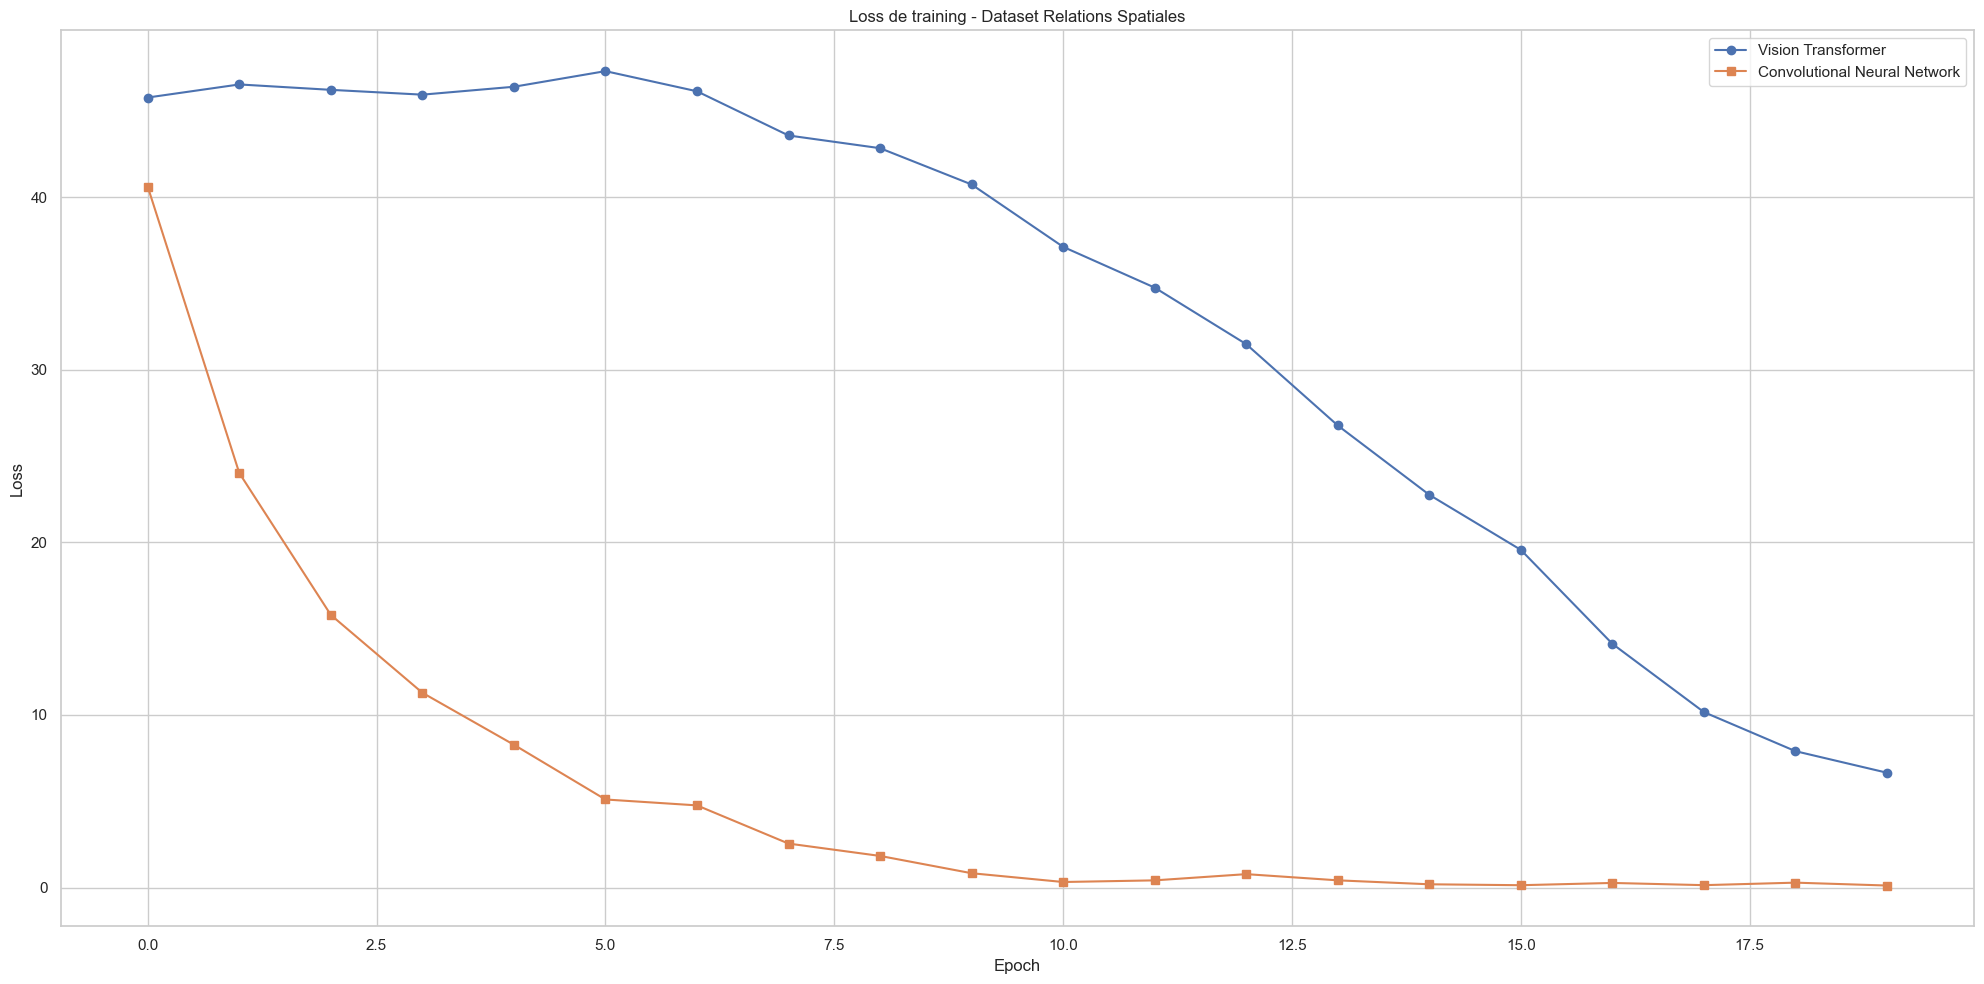

In [222]:
# Visualisation des résultats

# courbes de loss
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(20, 10))

plot_loss(
    ViT_pretrained_results_2D["train_loss"],
    mobilev3_results_2D["train_loss"],
    ax=ax
)

ax.set_title("Loss de training - Dataset Relations Spatiales")

plt.tight_layout()
plt.show()

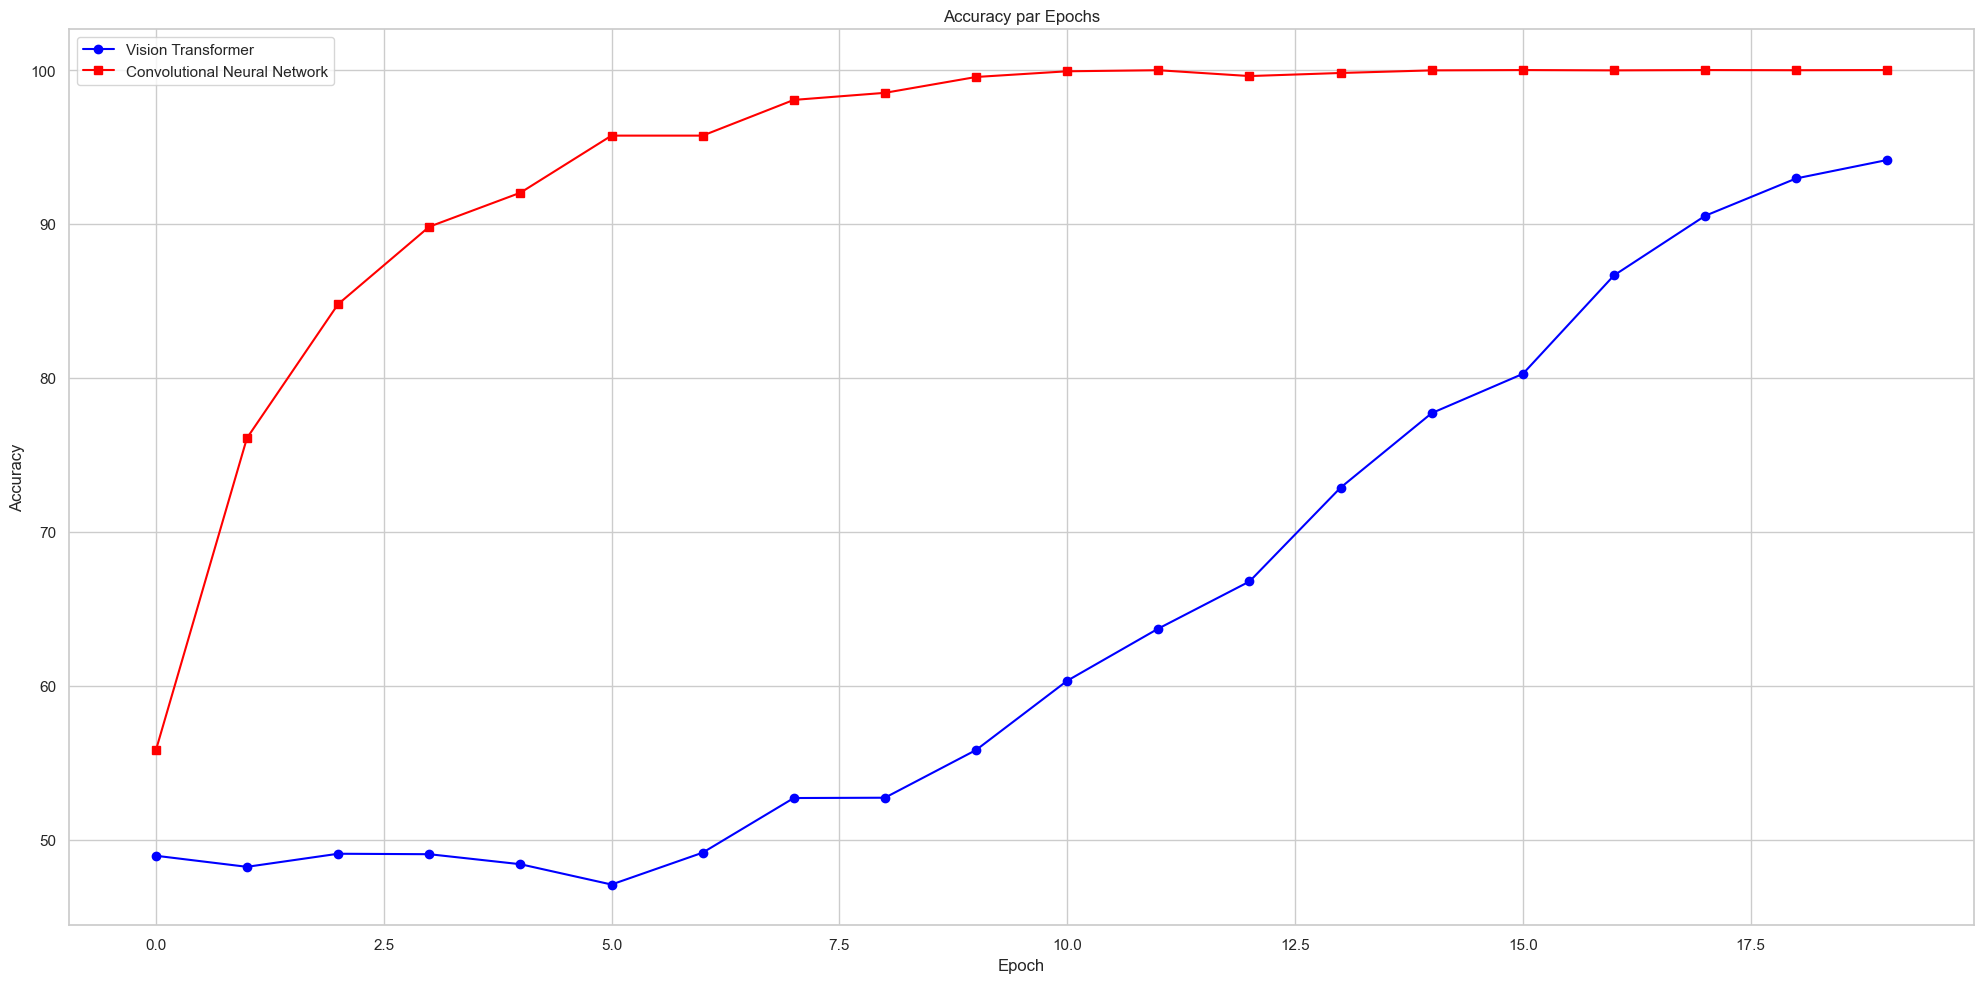

In [223]:
# courbes d'accuracy de training
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(20, 10))
plot_accuracy(
    ViT_pretrained_results_2D["train_acc"],
    mobilev3_results_2D["train_acc"],
    ax = ax
)

axes.set_title(f"Accuracy de training - Dataset Relations Spatiales")

plt.tight_layout()
plt.show()

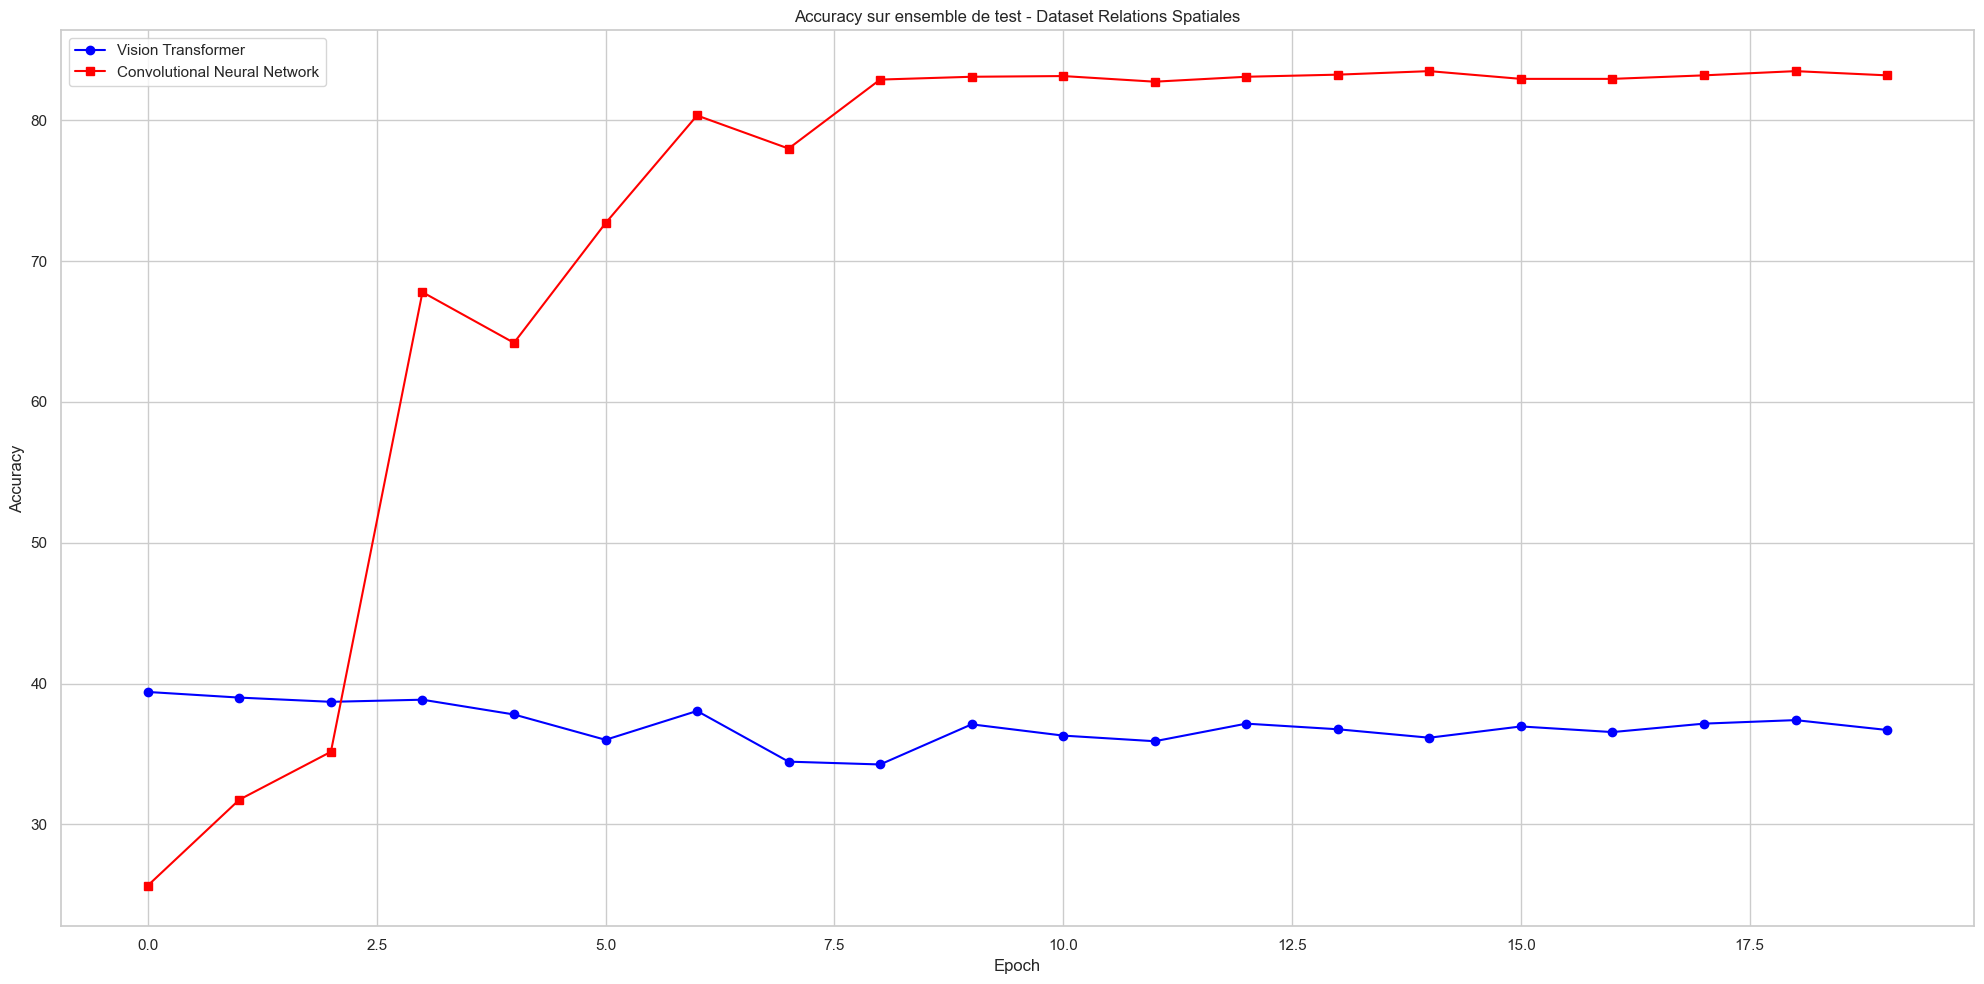

In [224]:
# courbes d'accuracy de test / capacité de généralisation
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(20, 10))

plot_accuracy(
    ViT_pretrained_results_2D["val_acc"],
    mobilev3_results_2D["val_acc"],
    ax = ax
)
ax.set_title(f"Accuracy sur ensemble de test - Dataset Relations Spatiales")

plt.tight_layout()
plt.show()

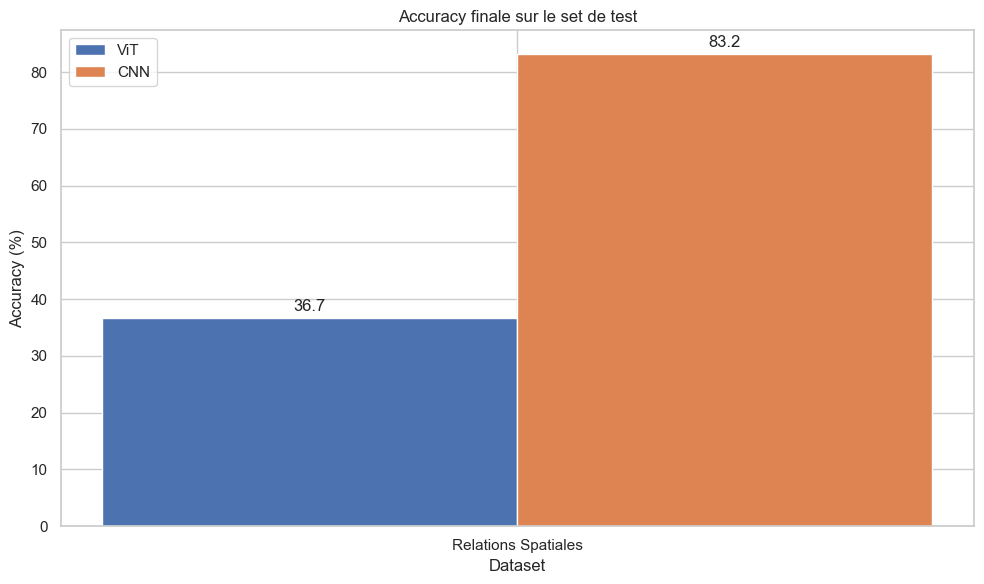

In [225]:
sns.set_theme(style="whitegrid")

width = 0.35
x = np.arange(1)  # une seule position
etiquettes = ["Relations Spatiales"]

valeurs_ViT = [ViT_pretrained_results_2D["val_acc"][-1]]
valeurs_CNN = [mobilev3_results_2D["val_acc"][-1]]

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, valeurs_ViT, width, label="ViT")
rects2 = ax.bar(x + width/2, valeurs_CNN, width, label="CNN")

ax.set_title("Accuracy finale sur le set de test")
ax.set_xlabel("Dataset")
ax.set_ylabel("Accuracy (%)")
ax.set_xticks(x)
ax.set_xticklabels(etiquettes)
ax.legend()

# Labels sur les barres
ax.bar_label(rects1, padding=3, fmt="%.1f")
ax.bar_label(rects2, padding=3, fmt="%.1f")

plt.tight_layout()
plt.show()

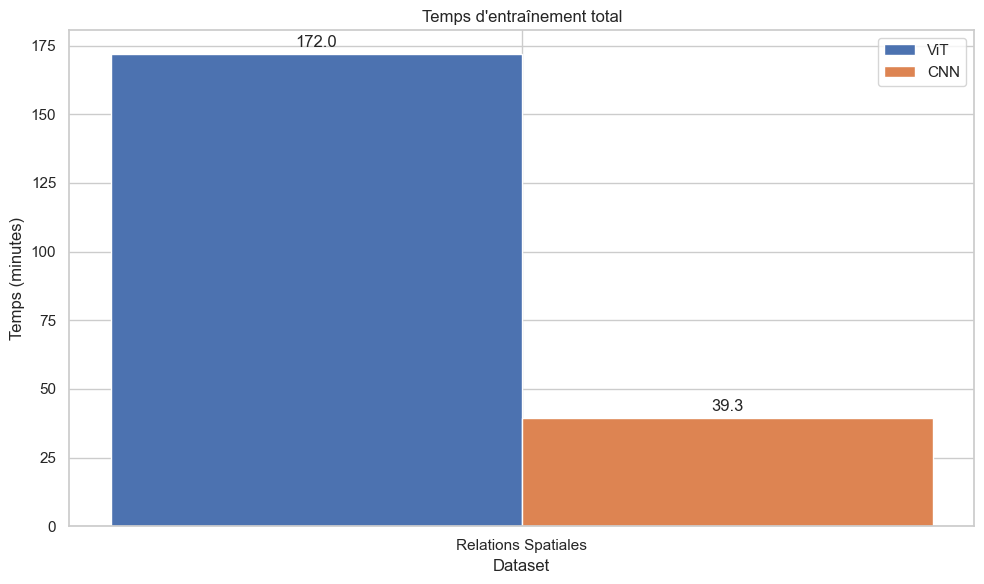

In [227]:
# Récupération des temps d'entraînement
temps_ViT = ViT_pretrained_training_time_2D/60 
temps_CNN = mobilev3_training_time_2D/60

# mettre en liste pour bar plot
temps_ViT = [temps_ViT]
temps_CNN = [temps_CNN]

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, temps_ViT, width, label="ViT")
rects2 = ax.bar(x + width/2, temps_CNN, width, label="CNN")

ax.set_title("Temps d'entraînement total")
ax.set_xlabel("Dataset")
ax.set_ylabel("Temps (minutes)")
ax.set_xticks(x)
ax.set_xticklabels(etiquettes)
ax.legend()

ax.bar_label(rects1, padding=3, fmt="%.1f")
ax.bar_label(rects2, padding=3, fmt="%.1f")

plt.tight_layout()
plt.show()

## Comptage de formes : Relations globales

Dans cette section, l'objectif est d'illustrer les capacités des ViTs à exploiter les dépendances globales. En effet, grâce aux mécansimes d'attention, les ViTs sont en mesure de "regarder toute l'image" en comparant tous les tokens entre eux. Au contraire, les CNNs présentent un biais inductif qui les favorise plutôt lorsque la classification se porte sur des motifs locaux (ex : texture). 

Le jeu de données est constitué d'image regroupant plusieurs formes géométriques : 
- Un nombre pair ou impair de cercles
- D'autres formes géométriques constituant du bruit

On se pose alors une question sur le comptage global des figures : Y a t'il un nombre pair de cercles ?
 

In [228]:
shape_dict = {
    0: square,
    1: triangle,
    2: polygon}

label_dict = {
    0: "pair",
    1: "impair"}

# je ne mets plus le rouge à l'écart pour les autres formes, pour éviter que le modèle puisse utiliser la couleur comme raccourci
def random_color():
    r = torch.randint(80,256,(1,))      
    g = torch.randint(80,256,(1,))
    b = torch.randint(80,256,(1,))
    return torch.tensor([r.item(), g.item(), b.item()], dtype=torch.float32).view(3,1)

def make_pairs(img, yy, xx, label, shape_dict = shape_dict):

    # Choisir pair ou impair
    if label == 0: # nombre pair de cercle
        n_circles = torch.randint(1, 4, (1,), generator=rng).item() * 2
    else : # nombre impair de cercle
        n_circles = torch.randint(0, 4, (1,), generator=rng).item() * 2 + 1

    for _ in range(n_circles):
        img, _ = circle(img, yy, xx, color_func=random_color)
    
    return img


def draw_picture_pairs(shape_dict = shape_dict, label_dict = label_dict):
    # Créer une image blanche de taille 240x240 pixels avec 3 canaux de couleur (RGB)
    img = torch.ones((3,224,224))*255
    _, h, w = img.shape
    yy, xx = torch.meshgrid(torch.arange(h), torch.arange(w), indexing="ij")


    # Sélectionner le nombre de formes supplémentaires à dessiner
    n_shapes = torch.randint(3, 10, (1,), generator=rng).item()
    # Sélectionner aléatoirement les formes supplémentairesà dessiner
    shapes = torch.randint(0, len(shape_dict), (n_shapes,), generator=rng)
    for shape in shapes :
        img, _ = shape_dict[int(shape)](img, yy, xx, color_func=random_color)

    # Créer la classe de l'image 
        # Choisir aléatoirement une relation
    label = torch.randint(0, len(label_dict), (1,), generator=rng).item()
    label_str = label_dict[label]
    img = make_pairs(img, yy, xx, label, shape_dict=shape_dict)
    return img, label_str, label

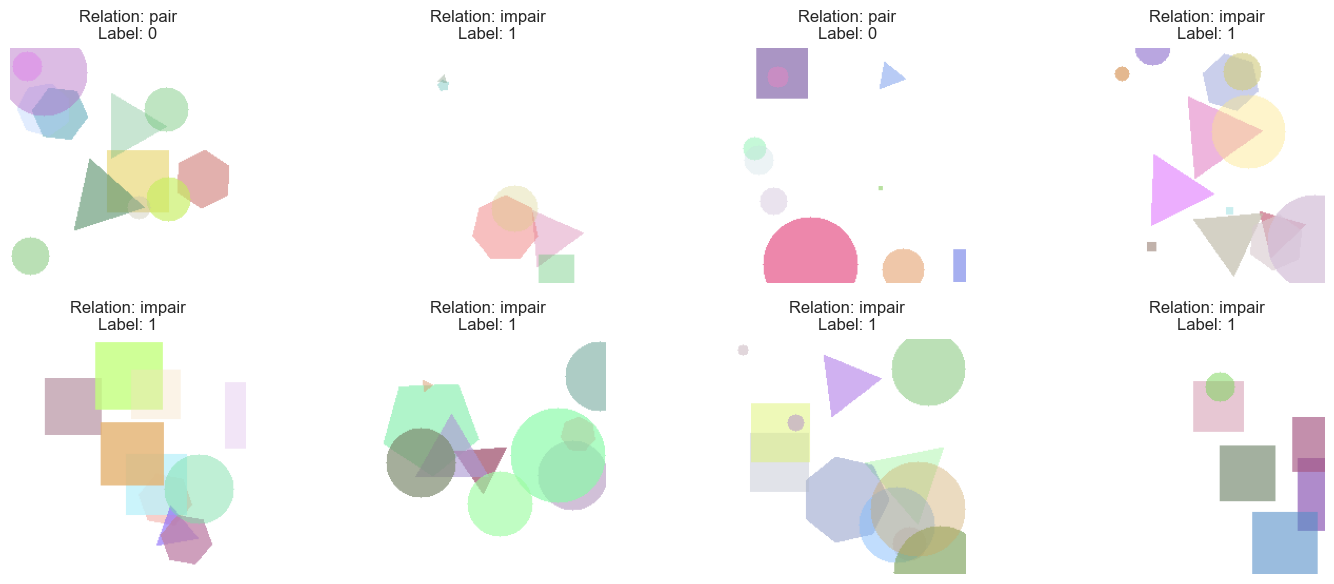

In [229]:
# Illustration de quelques images du dataset

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for i in range(8):
    img, relation, label = draw_picture_pairs()
    ax = axes[i//4, i%4]
    ax.imshow(img.permute(1,2,0).int())
    ax.set_title(f"Relation: {relation}\nLabel: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [230]:
# Générer un dataset d'entraînement et de test

class GlobalRelationDataset(torch.utils.data.Dataset):

    def __init__(self, n_samples):

        self.images = []
        self.labels = []

        for _ in range(n_samples):

            img, _, label = draw_picture_pairs()

            self.images.append(img)
            self.labels.append(label)

        self.images = torch.stack(self.images)
        self.labels = torch.tensor(self.labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

In [231]:
train_dataset = GlobalRelationDataset(10000)
test_dataset = GlobalRelationDataset(2000)

In [232]:
train_loader_global = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=0
)

test_loader_global = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

In [233]:
# ViT pré-entraîné
pretrained_tiny_vit_global = timm.create_model("vit_tiny_patch16_224", pretrained=True)
pretrained_tiny_vit_global.head = torch.nn.Linear(pretrained_tiny_vit_global.head.in_features, 2)

# Geler les paramètres
for param in pretrained_tiny_vit_global.parameters():
    param.requires_grad = False
for param in pretrained_tiny_vit_global.head.parameters():
    param.requires_grad = True
for block in pretrained_tiny_vit_global.blocks[-2:]:
    for param in block.parameters():
        param.requires_grad = True


In [234]:
pretrained_CNN_2D_global_weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1
pretrained_CNN_2D_global = mobilenet_v3_small(weights=pretrained_CNN_2D_global_weights)

# On remplace aussi la couche de classification et on adapte le nombre de classes
num_classes = 2
pretrained_CNN_2D_global.classifier[3] = torch.nn.Linear(
    pretrained_CNN_2D_global.classifier[3].in_features, num_classes
)


#Freeze tout
for param in pretrained_CNN_2D_global.parameters():
    param.requires_grad = False

#Unfreeze la head
for param in pretrained_CNN_2D_global.classifier.parameters():
    param.requires_grad = True

# Unfreeze les dernières couches du backbone
# (équivalent "2 derniers blocks")
for param in pretrained_CNN_2D_global.features[-2:].parameters():
    param.requires_grad = True

#Compter paramètres entraînables
n_params = sum(p.numel() for p in pretrained_CNN_2D_global.parameters() if p.requires_grad)
print(f"Nombre de paramètres entraînables : {n_params:,}")



Nombre de paramètres entraînables : 943,442


In [235]:
# Training ViT sur tâche globale
print("=== Entraînement ViT pré-entraîné — Dataset Relations Globales ===")
start_time = time.time()
ViT_pretrained_results_global = train_model(pretrained_tiny_vit_global, 
                          train_loader_global, 
                          test_loader_global, 
                          nb_classes=2, 
                          epochs=epochs,
                          lr=0.002,
                          weight_decay=5e-2)
end_time = time.time()
ViT_pretrained_training_time_global = end_time - start_time


=== Entraînement ViT pré-entraîné — Dataset Relations Globales ===
Epoch 0 | Loss: 29.72 | Train Acc: 50.000% | Val Acc: 48.850%
Epoch 1 | Loss: 29.40 | Train Acc: 49.600% | Val Acc: 49.450%
Epoch 2 | Loss: 29.64 | Train Acc: 49.490% | Val Acc: 49.450%
Epoch 3 | Loss: 28.09 | Train Acc: 50.120% | Val Acc: 50.450%


c:\Users\nanou\anaconda3\envs\vit_cnn_projet_m2\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 4 | Loss: 28.22 | Train Acc: 50.280% | Val Acc: 50.550%
Epoch 5 | Loss: 28.23 | Train Acc: 50.450% | Val Acc: 50.550%
Epoch 6 | Loss: 28.48 | Train Acc: 51.150% | Val Acc: 49.000%
Epoch 7 | Loss: 28.17 | Train Acc: 51.940% | Val Acc: 49.600%
Epoch 8 | Loss: 27.71 | Train Acc: 52.860% | Val Acc: 48.850%
Epoch 9 | Loss: 27.48 | Train Acc: 55.240% | Val Acc: 48.350%
Epoch 10 | Loss: 27.46 | Train Acc: 55.590% | Val Acc: 49.500%
Epoch 11 | Loss: 27.14 | Train Acc: 57.240% | Val Acc: 49.300%
Epoch 12 | Loss: 26.75 | Train Acc: 60.010% | Val Acc: 50.750%
Epoch 13 | Loss: 27.05 | Train Acc: 58.160% | Val Acc: 49.350%
Epoch 14 | Loss: 25.85 | Train Acc: 61.950% | Val Acc: 49.050%
Epoch 15 | Loss: 25.72 | Train Acc: 62.210% | Val Acc: 49.200%
Epoch 16 | Loss: 25.40 | Train Acc: 63.280% | Val Acc: 49.900%
Epoch 17 | Loss: 24.93 | Train Acc: 64.470% | Val Acc: 49.950%
Epoch 18 | Loss: 24.71 | Train Acc: 65.650% | Val Acc: 49.800%
Epoch 19 | Loss: 24.47 | Train Acc: 65.960% | Val Acc: 50.250

In [236]:
# Training CNN sur tâche globale
print("=== Entraînement CNN pré-entraîné — Dataset Relations Globales ===")
start_time = time.time()
CNN_pretrained_results_global = train_model(pretrained_CNN_2D_global,
                                        train_loader_global, 
                                        test_loader_global, 
                                        nb_classes=2, 
                                        epochs=epochs, 
                                        lr=1e-3, 
                                        weight_decay=1e-4)
end_time = time.time()
CNN_pretrained_training_time_global = end_time - start_time

=== Entraînement CNN pré-entraîné — Dataset Relations Globales ===
Epoch 0 | Loss: 28.05 | Train Acc: 52.340% | Val Acc: 50.850%
Epoch 1 | Loss: 26.24 | Train Acc: 60.690% | Val Acc: 50.600%
Epoch 2 | Loss: 24.66 | Train Acc: 64.930% | Val Acc: 50.600%
Epoch 3 | Loss: 22.36 | Train Acc: 71.110% | Val Acc: 49.950%
Epoch 4 | Loss: 18.24 | Train Acc: 78.630% | Val Acc: 52.050%
Epoch 5 | Loss: 13.42 | Train Acc: 85.440% | Val Acc: 53.000%
Epoch 6 | Loss: 8.69 | Train Acc: 91.760% | Val Acc: 50.950%
Epoch 7 | Loss: 6.43 | Train Acc: 93.990% | Val Acc: 51.700%
Epoch 8 | Loss: 2.55 | Train Acc: 98.360% | Val Acc: 50.900%
Epoch 9 | Loss: 1.40 | Train Acc: 99.280% | Val Acc: 50.950%
Epoch 10 | Loss: 1.40 | Train Acc: 98.990% | Val Acc: 51.900%
Epoch 11 | Loss: 0.93 | Train Acc: 99.400% | Val Acc: 51.850%
Epoch 12 | Loss: 0.48 | Train Acc: 99.890% | Val Acc: 52.400%
Epoch 13 | Loss: 0.43 | Train Acc: 99.910% | Val Acc: 52.200%
Epoch 14 | Loss: 0.49 | Train Acc: 99.810% | Val Acc: 52.150%
Epoch 1

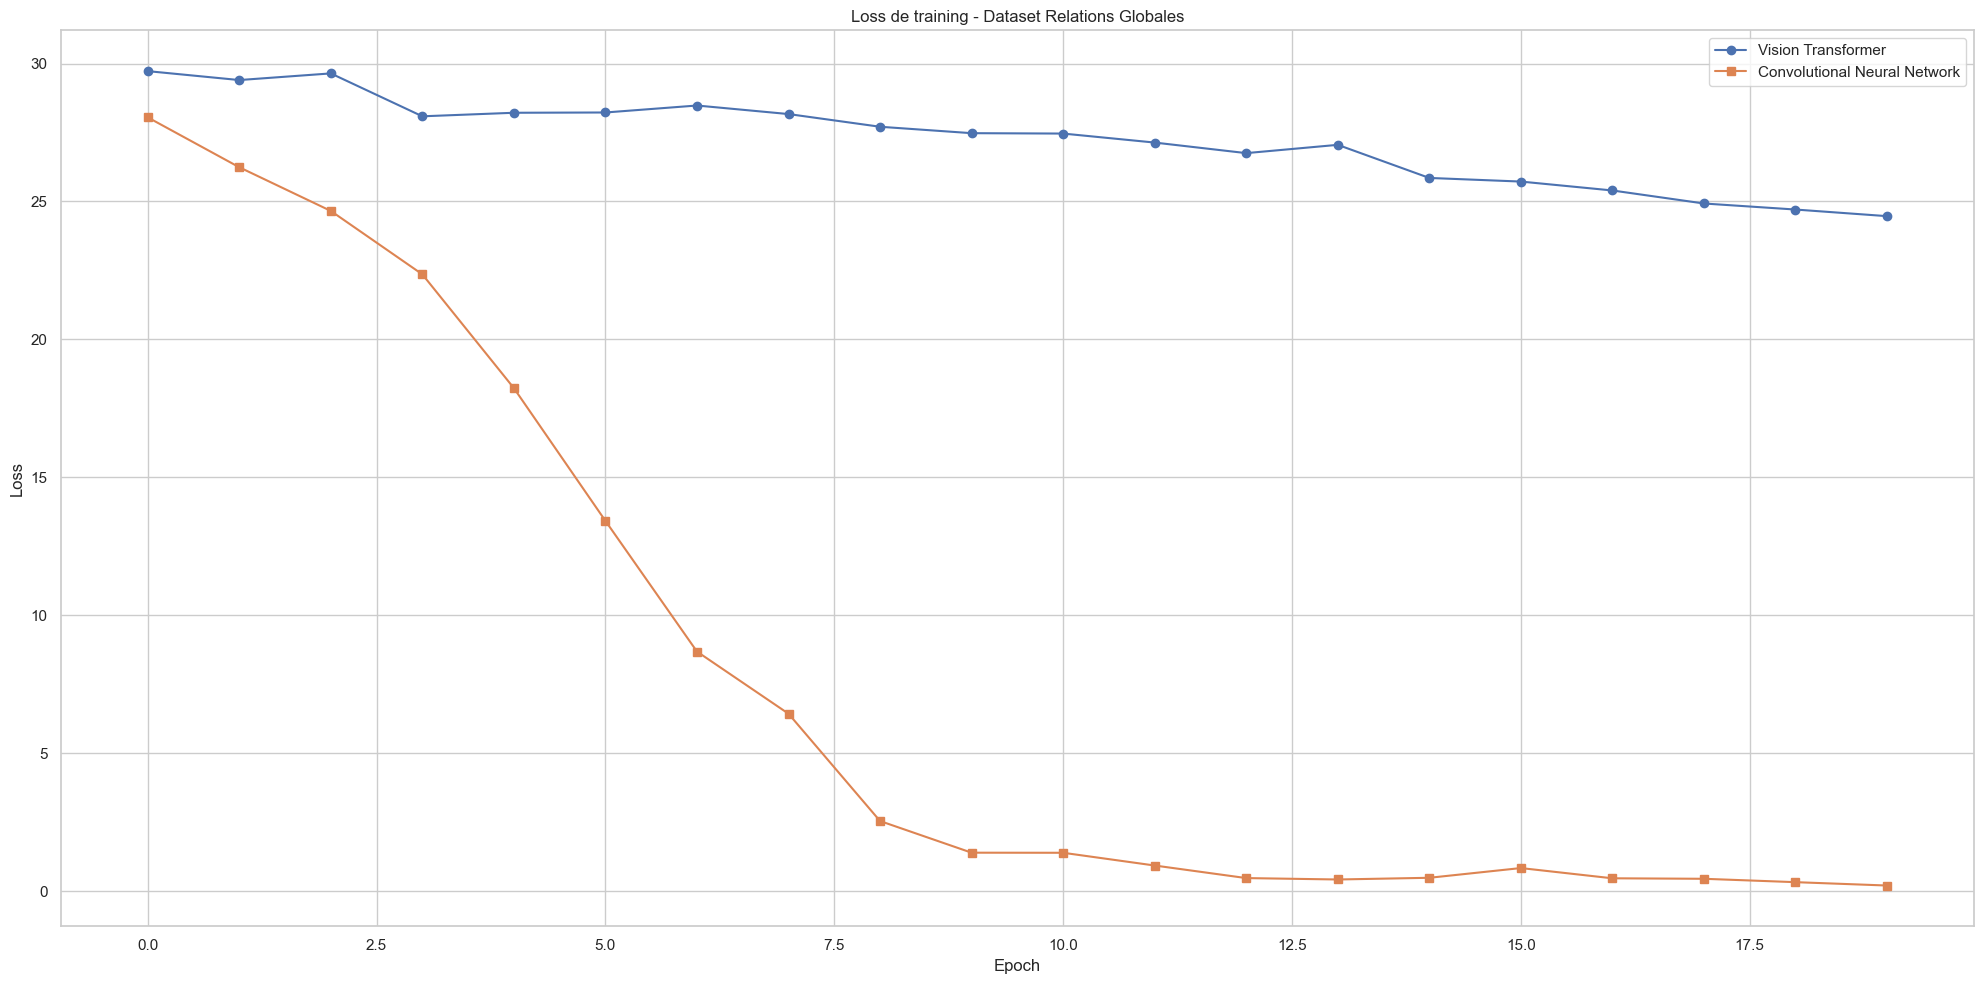

In [237]:
# Visualisation des résultats

# courbes de loss
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(20, 10))

plot_loss(
    ViT_pretrained_results_global["train_loss"],
    CNN_pretrained_results_global["train_loss"],
    ax=ax
)
ax.set_title(f"Loss de training - Dataset Relations Globales")
plt.tight_layout()
plt.show()



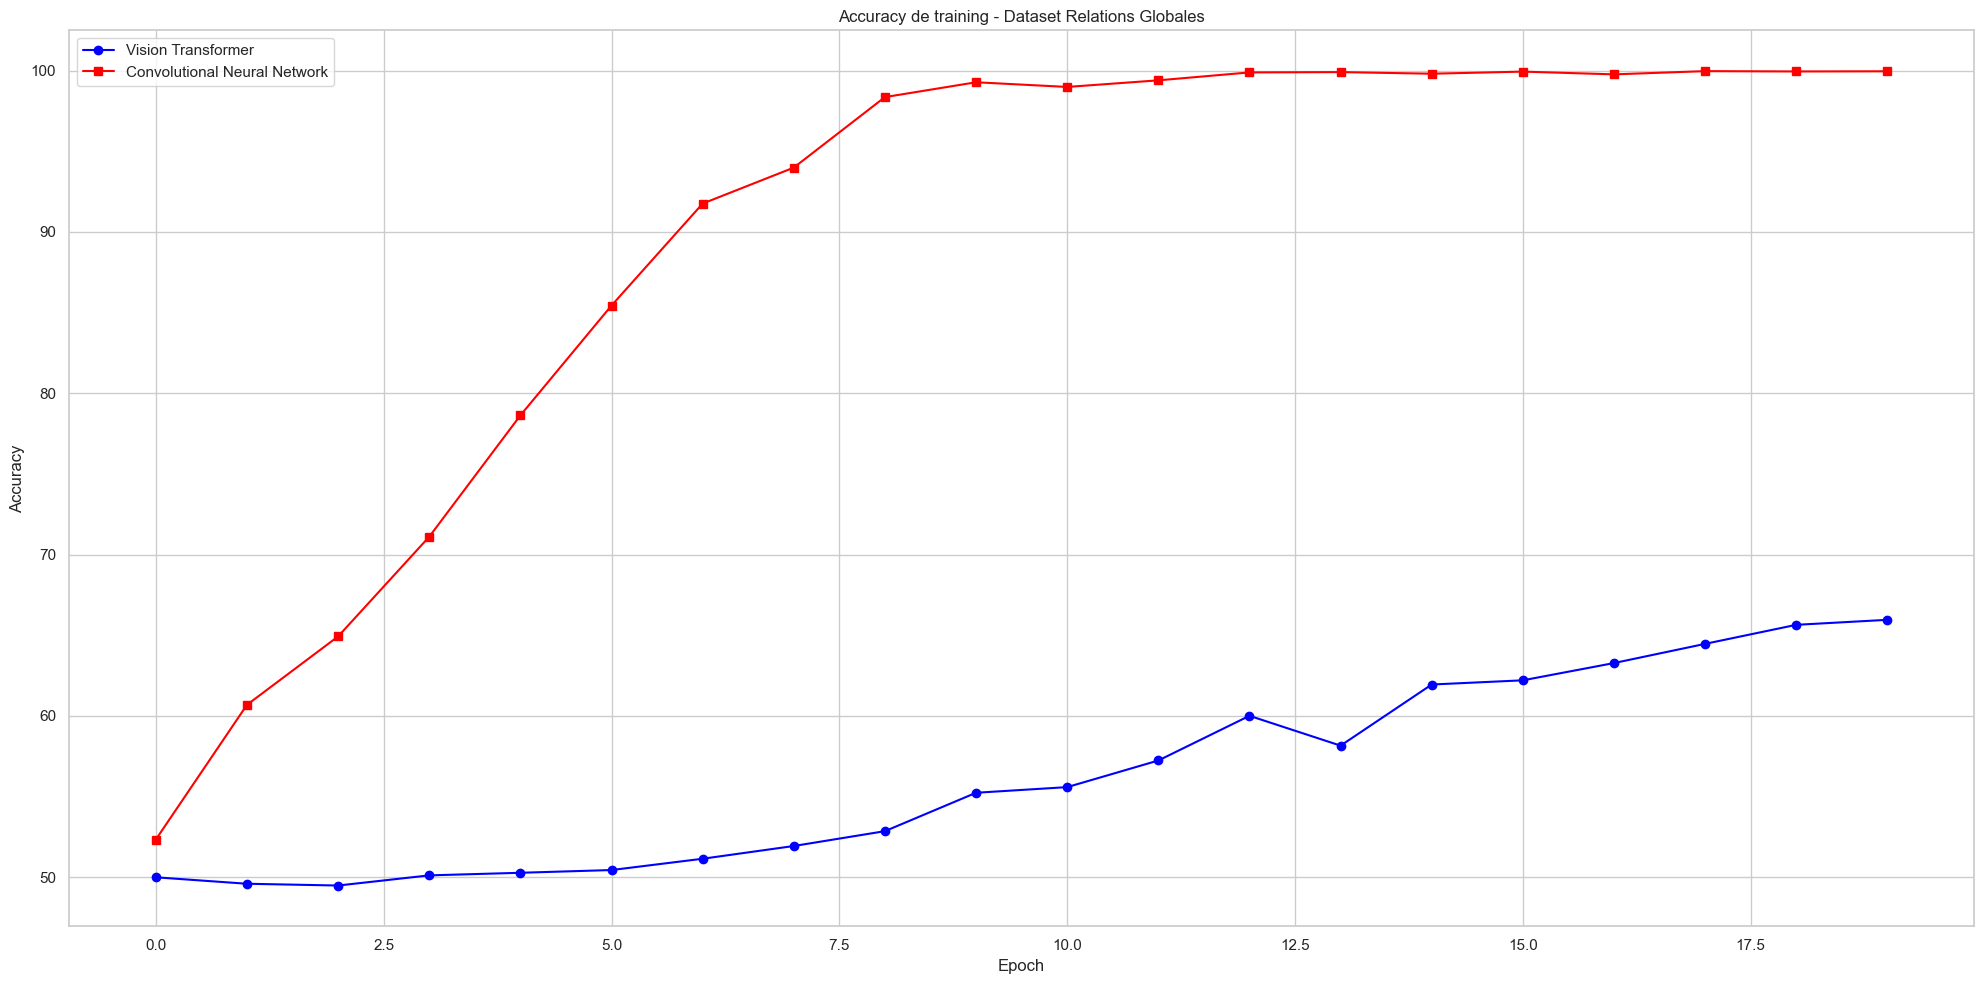

In [238]:
# courbes d'accuracy de training
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(20, 10))
plot_accuracy(
    ViT_pretrained_results_global["train_acc"],
    CNN_pretrained_results_global["train_acc"],
    ax=ax
)
ax.set_title(f"Accuracy de training - Dataset Relations Globales")
plt.tight_layout()
plt.show()

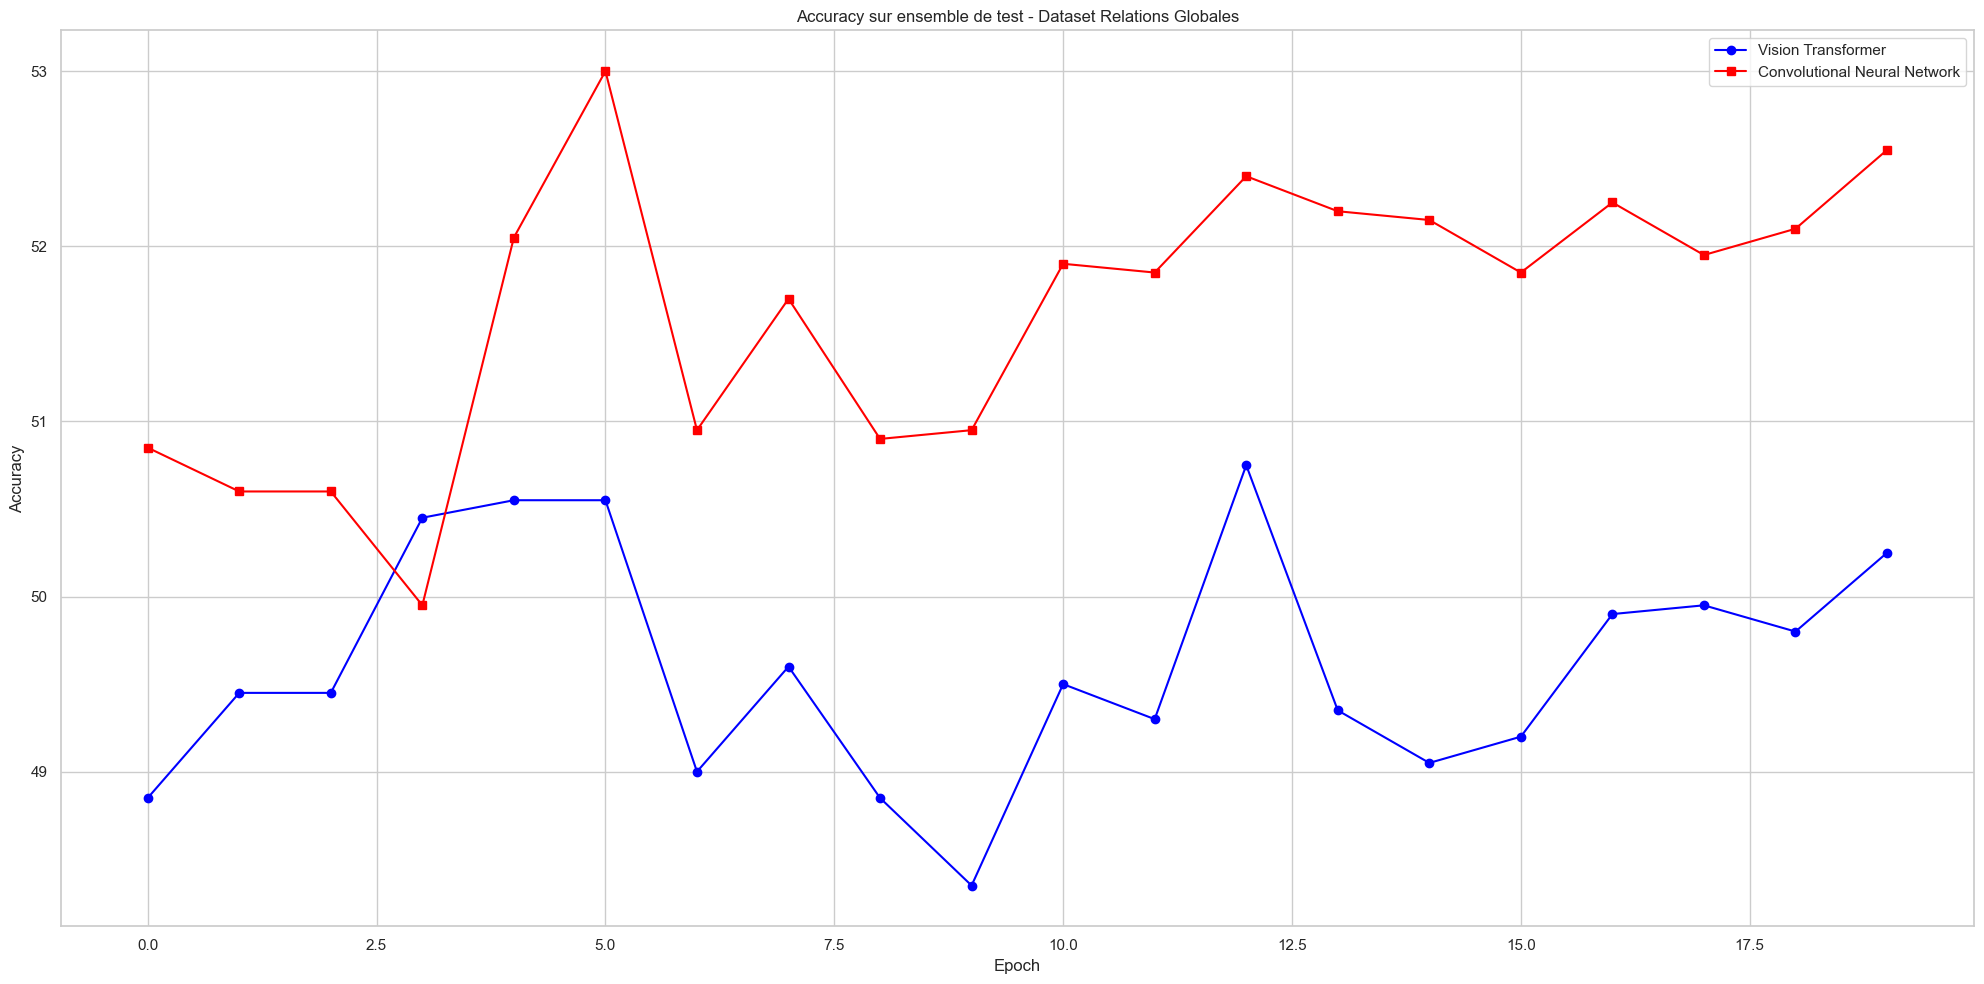

In [239]:
# courbes d'accuracy sur ensemble de test
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(20, 10))
plot_accuracy(
    ViT_pretrained_results_global["val_acc"],
    CNN_pretrained_results_global["val_acc"],
    ax=ax
)
ax.set_title(f"Accuracy sur ensemble de test - Dataset Relations Globales")
plt.tight_layout()
plt.show()

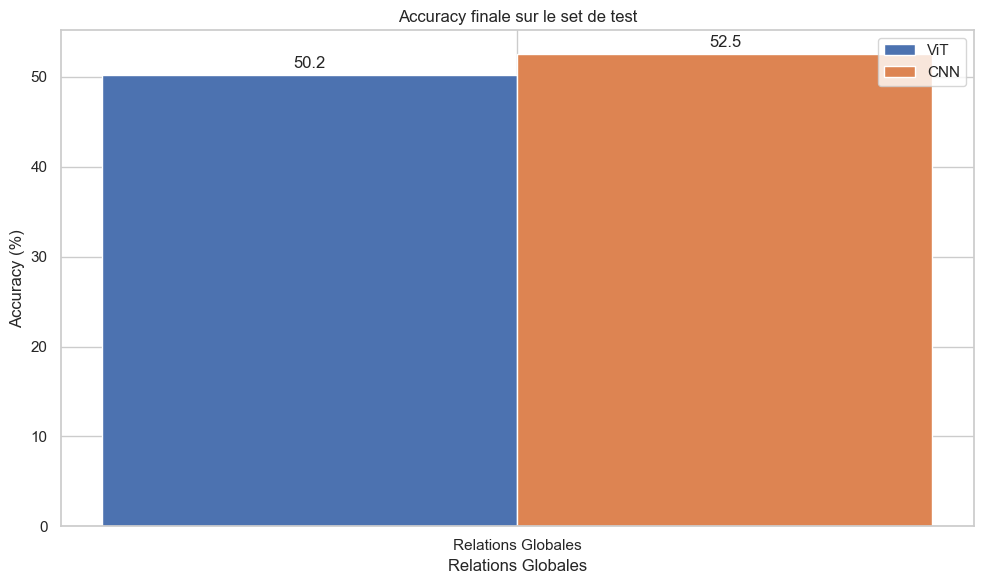

In [251]:
# Evaluation finale
sns.set_theme(style="whitegrid")
width = 0.35
x = np.arange(1)  # une seule barre pour chaque modèle
etiquettes = ["Relations Globales"]
valeurs_ViT = [ViT_pretrained_results_global["val_acc"][-1]]
valeurs_CNN = [CNN_pretrained_results_global["val_acc"][-1]]
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, valeurs_ViT, width, label="ViT")
rects2 = ax.bar(x + width/2, valeurs_CNN, width, label="CNN")
ax.set_title("Accuracy finale sur le set de test")
ax.set_xlabel("Relations Globales")
ax.set_ylabel("Accuracy (%)")
ax.set_xticks(x)
ax.set_xticklabels(etiquettes)
ax.legend()
ax.bar_label(rects1, padding=3, fmt="%.1f")
ax.bar_label(rects2, padding=3, fmt="%.1f")
plt.tight_layout()
plt.show()

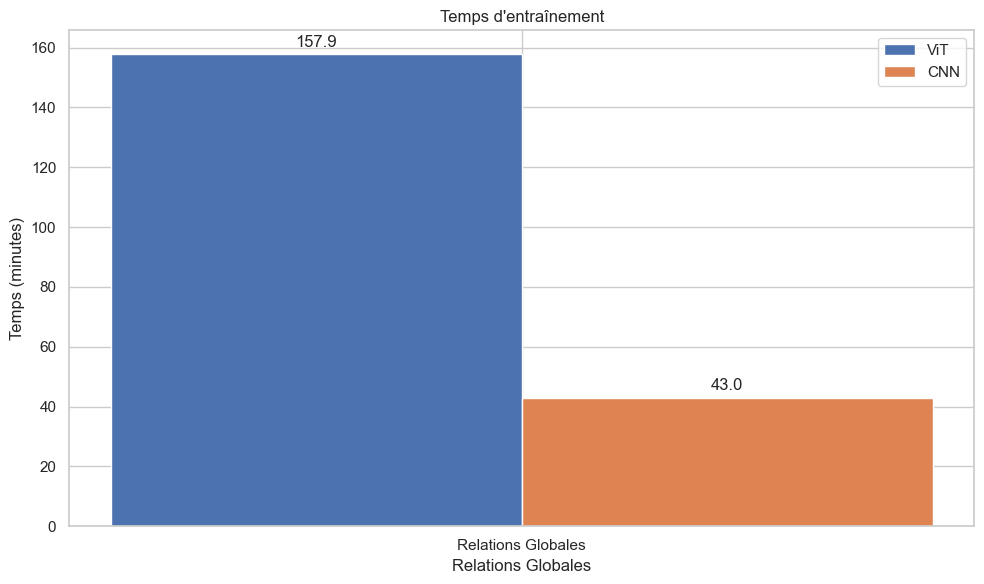

In [241]:
# Récupération des temps d'entraînement
temps_ViT_global = ViT_pretrained_training_time_global/60
temps_CNN_global = CNN_pretrained_training_time_global/60
# mettre en liste pour bar plot
temps_ViT_global = [temps_ViT_global]
temps_CNN_global = [temps_CNN_global]
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, temps_ViT_global, width, label="ViT")
rects2 = ax.bar(x + width/2, temps_CNN_global, width, label="CNN")
ax.set_title("Temps d'entraînement")
ax.set_xlabel("Relations Globales")
ax.set_ylabel("Temps (minutes)")
ax.set_xticks(x)
ax.set_xticklabels(etiquettes)
ax.legend()
ax.bar_label(rects1, padding=3, fmt="%.1f")
ax.bar_label(rects2, padding=3, fmt="%.1f")
plt.tight_layout()
plt.show()